# Evaluation der Metriken

Dieses Notebook wertet die szenariobasierten Feldtests des Artefakts systematisch aus. Die Analyse gliedert sich in neun Abschnitte:

1. **Datenimport und Vorverarbeitung** – Laden der CSV-Logs, Zuordnung zu Szenarien und Modi
2. **Trainings- und Modellgüte-Evaluation (FA-02 / FA-03)** – Konvergenz, mAP, Precision/Recall gesamt & pro Klasse, Checkpoint-Selektion
3. **Pipeline-Performance (FA-01 / NFA-01 / NFA-02)** – Bildrate, Latenz, Teilzeiten
4. **Stabilitäts- und Robustheitsanalyse (NFA-05)** – Stalls, Drop-Rate, Korrelation det_count ↔ e2e_ms
5. **Warnlogik-Analyse (FA-04 – FA-10)** – Zone, Proximity, DangerScore, Cooldown, Motion, Orientierungshinweise
6. **Ablationsvergleich DangerScore vs. Confidence-Only (FA-06)**
7. **Log-Vollständigkeit & Metadaten (FA-12 / NFA-07)**
8. **Szenarioübergreifende Gesamtübersicht**
9. **Anforderungs-Deckungsmatrix**

**Referenzgerät:** Samsung Galaxy S20 FE (SM-G780G), Android 13  
**Modell:** YOLOv8n (obstacle_mvp_15c.onnx), Eingabe 640×640  
**Konfiguration:** conf=0.30, NMS-IoU=0.45, TTS-Rate=1.25×

> **Hinweis:** Die Anforderungen NFA-03 (Offline-Fähigkeit), NFA-04 (Datenschutz), NFA-08 (Portabilität) und FA-11 (Overlay)
> erfordern qualitative Code- bzw. visuelle Inspektion und werden in einem separaten Dokument behandelt (siehe Anhang der Arbeit).

## 1. Datenimport und Vorverarbeitung

In [1]:
import pandas as pd
import numpy as np
import os, glob

DS_DIR = "Fußgänger und Straßendrand mit Dangerscore am 27_28_02"
CO_DIR = "Fußgänger und Straßendrand mit Confidencescore am 27_28_02"

def load_runs(directory):
    runs = {}
    for f in sorted(glob.glob(f"{directory}/frame_metrics_*")):
        name = os.path.basename(f).replace("frame_metrics_", "")
        if "ngerzone" in name:
            scenario = "S3"
        elif "Stadtzentrum" in name:
            scenario = "S2"
        elif "Wohngebiet" in name:
            scenario = "S1"
        else:
            scenario = "XX"
        lauf = name.split("Lauf_")[-1] if "Lauf_" in name else name.split("Lauf")[-1]
        key = f"{scenario}_L{lauf}"

        df = pd.read_csv(f, sep=";")
        df = df.iloc[5:]  # Warm-up-Frames überspringen
        duration_s = (df['timestamp_ms'].max() - df['timestamp_ms'].min()) / 1000

        we_file = f.replace("frame_metrics_", "warn_events_")
        we_df = pd.read_csv(we_file, sep=";") if os.path.exists(we_file) else pd.DataFrame()

        runs[key] = {
            "fm": df,
            "we": we_df,
            "scenario": scenario,
            "duration_s": duration_s,
        }
    return runs

ds_runs = load_runs(DS_DIR)
co_runs = load_runs(CO_DIR)

print(f"  DangerScore:     {len(ds_runs)} Läufe geladen")
print(f"  Confidence-Only: {len(co_runs)} Läufe geladen")
print()

print(f"  {'Modus':<6s} {'Lauf':<12s} {'Frames':>8s} {'Dauer':>8s} {'Warnungen':>10s} {'Selection Mode'}")
print(f"  {'─' * 72}")

for key in sorted(ds_runs):
    r = ds_runs[key]
    print(f"  {'DS':<6s} {key:<12s} {len(r['fm']):>7d}  {r['duration_s']:>6.0f}s {len(r['we']):>9d}  {r['fm']['selection_mode'].iloc[0]}")

print()
for key in sorted(co_runs):
    r = co_runs[key]
    print(f"  {'CO':<6s} {key:<12s} {len(r['fm']):>7d}  {r['duration_s']:>6.0f}s {len(r['we']):>9d}  {r['fm']['selection_mode'].iloc[0]}")

  DangerScore:     9 Läufe geladen
  Confidence-Only: 9 Läufe geladen

  Modus  Lauf           Frames    Dauer  Warnungen Selection Mode
  ────────────────────────────────────────────────────────────────────────
  DS     S1_L1           1195     187s        42  DANGER_SCORE
  DS     S1_L2           1285     197s        45  DANGER_SCORE
  DS     S1_L3           1255     193s        46  DANGER_SCORE
  DS     S2_L1           1015     188s        48  DANGER_SCORE
  DS     S2_L2            985     180s        43  DANGER_SCORE
  DS     S2_L3            985     179s        36  DANGER_SCORE
  DS     S3_L1            715     179s        33  DANGER_SCORE
  DS     S3_L2           1045     177s        66  DANGER_SCORE
  DS     S3_L3            715     117s        41  DANGER_SCORE

  CO     S1_L1           1225     189s        40  CONFIDENCE_ONLY
  CO     S1_L2           1225     188s        37  CONFIDENCE_ONLY
  CO     S1_L3           1225     187s        36  CONFIDENCE_ONLY
  CO     S2_L1        

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Farbpalette für konsistente Darstellung
COLORS = {
    'S1': '#2196F3',   # Blau
    'S2': '#FF9800',   # Orange
    'S3': '#F44336',   # Rot
    'DS': '#4CAF50',   # Grün (DangerScore)
    'CO': '#9C27B0',   # Lila (Confidence-Only)
}

SCENARIO_LABELS = {
    'S1': 'S1: Wohngebiet',
    'S2': 'S2: Stadtzentrum',
    'S3': 'S3: Fußgängerzone',
}

def aggregate(runs_dict, scenarios=None):
    if scenarios is None:
        scenarios = sorted(set(r['scenario'] for r in runs_dict.values()))
    result = {}
    for s in scenarios:
        keys = [k for k, r in runs_dict.items() if r['scenario'] == s]
        if not keys:
            continue
        fm = pd.concat([runs_dict[k]['fm'] for k in keys], ignore_index=True)
        we = pd.concat([runs_dict[k]['we'] for k in keys], ignore_index=True)
        dur = sum(runs_dict[k]['duration_s'] for k in keys)
        result[s] = {'fm': fm, 'we': we, 'duration_s': dur, 'n_runs': len(keys)}
    return result

ds_agg = aggregate(ds_runs)
co_agg = aggregate(co_runs)

In [3]:
print("Aggregierte Datenbasis (DangerScore):")
print(f"  {'Szenario':<30s} {'Frames':>8s} {'Dauer':>8s} {'Warnungen':>10s} {'Läufe':>7s}")
print(f"  {'─' * 65}")
for s, d in ds_agg.items():
    print(f"  {SCENARIO_LABELS[s]:<30s} {len(d['fm']):>7d}  {d['duration_s']:>6.0f}s {len(d['we']):>9d}  {d['n_runs']:>5d}")

print()
print("Aggregierte Datenbasis (Confidence-Only):")
print(f"  {'Szenario':<30s} {'Frames':>8s} {'Dauer':>8s} {'Warnungen':>10s} {'Läufe':>7s}")
print(f"  {'─' * 65}")
for s, d in co_agg.items():
    print(f"  {SCENARIO_LABELS[s]:<30s} {len(d['fm']):>7d}  {d['duration_s']:>6.0f}s {len(d['we']):>9d}  {d['n_runs']:>5d}")

Aggregierte Datenbasis (DangerScore):
  Szenario                         Frames    Dauer  Warnungen   Läufe
  ─────────────────────────────────────────────────────────────────
  S1: Wohngebiet                    3735     577s       133      3
  S2: Stadtzentrum                  2985     547s       127      3
  S3: Fußgängerzone                 2475     473s       140      3

Aggregierte Datenbasis (Confidence-Only):
  Szenario                         Frames    Dauer  Warnungen   Läufe
  ─────────────────────────────────────────────────────────────────
  S1: Wohngebiet                    3675     564s       113      3
  S2: Stadtzentrum                  3225     576s       143      3
  S3: Fußgängerzone                 2565     486s       172      3


## 2. Trainings- und Modellgüte-Evaluation (FA-02 / FA-03)

Dieses Kapitel wertet die Trainingslogs des YOLOv8n-Finetunings aus.  
Die Daten werden aus einer separaten Log-Datei eingelesen (z. B. `Erstes_Finetunen.py` oder einer YOLO-`results.csv`).

**Abgedeckte Metriken (FA-02):** box_loss, cls_loss, dfl_loss (Konvergenz); mAP50, mAP50-95, Precision, Recall (Validierung); gewählter Checkpoint / Epoche  
**Abgedeckte Metriken (FA-03):** Precision/Recall pro Klasse (aus separater per-class-Auswertung)

### 2.1 Trainingslog einlesen und parsen

In [4]:
import re

# ── Trainingslog einlesen ──────────────────────────────────────────
# Pfad zur Trainingslog-Datei anpassen:
TRAINING_LOG_PATH = "Erstes_Finetunen.py"

with open(TRAINING_LOG_PATH, 'r', encoding='utf-8') as f:
    log_content = f.read()

# ── Regex-Parsing der YOLO-Ausgabe ─────────────────────────────────
# Training: Epoch, box_loss, cls_loss, dfl_loss
train_pattern = re.compile(
    r'\s+(\d+)/\d+\s+\dG\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+\d+\s+640.*?100%'
)
# Validation: Precision, Recall, mAP50, mAP50-95
val_pattern = re.compile(
    r'\s+all\s+\d+\s+\d+\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)'
)

train_matches = train_pattern.findall(log_content)
val_matches = val_pattern.findall(log_content)

# Nur vollständige Epochen (Training + Validation vorhanden)
n_complete = min(len(train_matches), len(val_matches))

train_df = pd.DataFrame(train_matches[:n_complete],
    columns=['epoch', 'box_loss', 'cls_loss', 'dfl_loss']).astype(float)
train_df['epoch'] = train_df['epoch'].astype(int)

val_df = pd.DataFrame(val_matches[:n_complete],
    columns=['Precision', 'Recall', 'mAP50', 'mAP50_95']).astype(float)
val_df['epoch'] = train_df['epoch'].values

# Zusammenführen
training_df = pd.merge(train_df, val_df, on='epoch')

print(f"Trainingslog geparst: {n_complete} vollständige Epochen (von {len(train_matches)} Trainings-Epochen)")
print(f"Letzte vollständige Epoche: {training_df['epoch'].max()}")
display(training_df.tail(5).style.format(precision=4).set_caption("Letzte 5 vollständige Epochen"))

Trainingslog geparst: 30 vollständige Epochen (von 30 Trainings-Epochen)
Letzte vollständige Epoche: 30


,epoch,box_loss,cls_loss,dfl_loss,Precision,Recall,mAP50,mAP50_95
25,26,1.0110,1.0940,1.0730,0.6460,0.4870,0.5880,0.3940
26,27,1.0030,1.0480,1.0670,0.7030,0.5740,0.6130,0.4020
27,28,1.0130,1.0510,1.0640,0.6740,0.5690,0.6110,0.4030
28,29,0.9877,1.0400,1.0550,0.6320,0.5970,0.6170,0.3920
29,30,0.9711,0.9807,1.0410,0.6680,0.5860,0.5870,0.3900


### 2.2 Trainingskonvergenz: Loss-Kurven (FA-02)

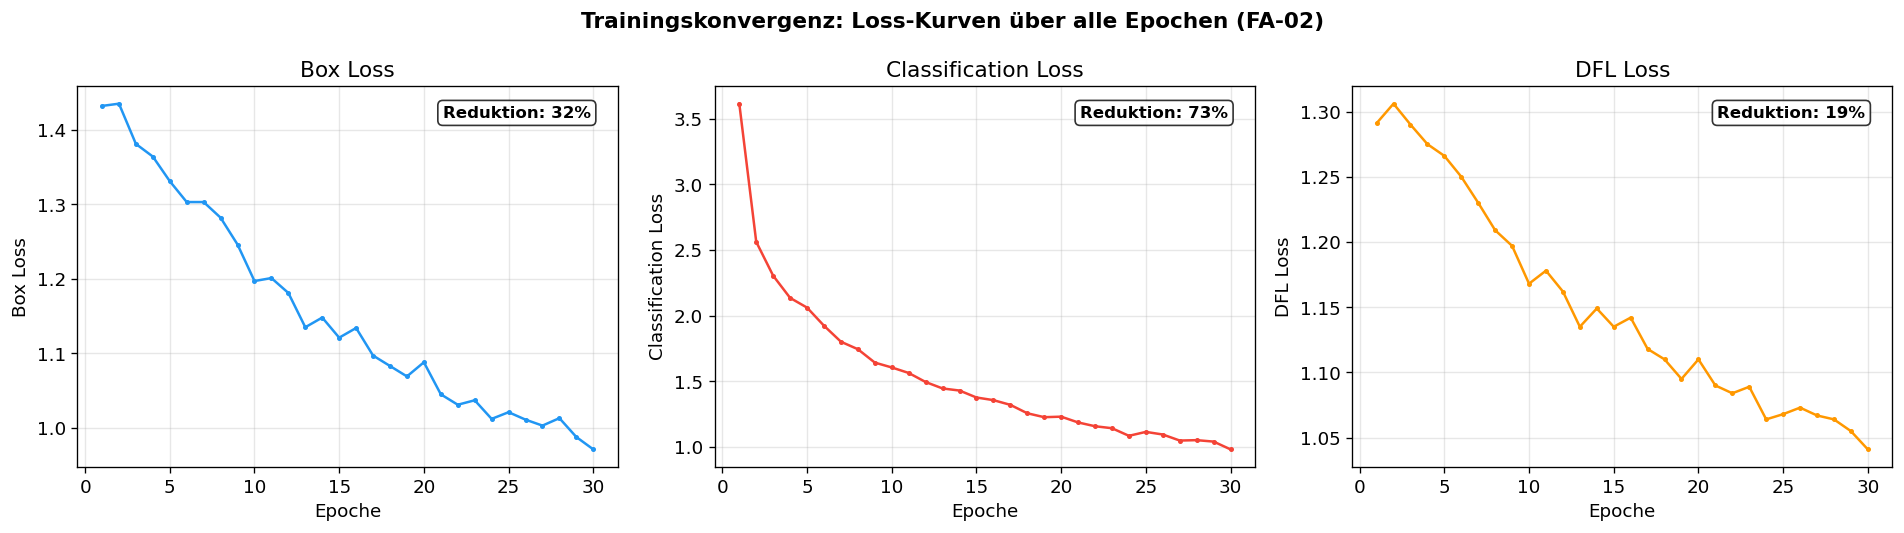

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)

for ax, col, label, color in zip(axes,
    ['box_loss', 'cls_loss', 'dfl_loss'],
    ['Box Loss', 'Classification Loss', 'DFL Loss'],
    ['#2196F3', '#F44336', '#FF9800']):
    ax.plot(training_df['epoch'], training_df[col], marker='.', color=color, linewidth=1.5, markersize=4)
    ax.set_xlabel('Epoche')
    ax.set_ylabel(label)
    ax.set_title(label)
    first_val = training_df[col].iloc[0]
    last_val = training_df[col].iloc[-1]
    reduction = (1 - last_val / first_val) * 100
    ax.annotate(f'Reduktion: {reduction:.0f}%', xy=(0.95, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Trainingskonvergenz: Loss-Kurven über alle Epochen (FA-02)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Validierungsmetriken: mAP, Precision, Recall (FA-02)

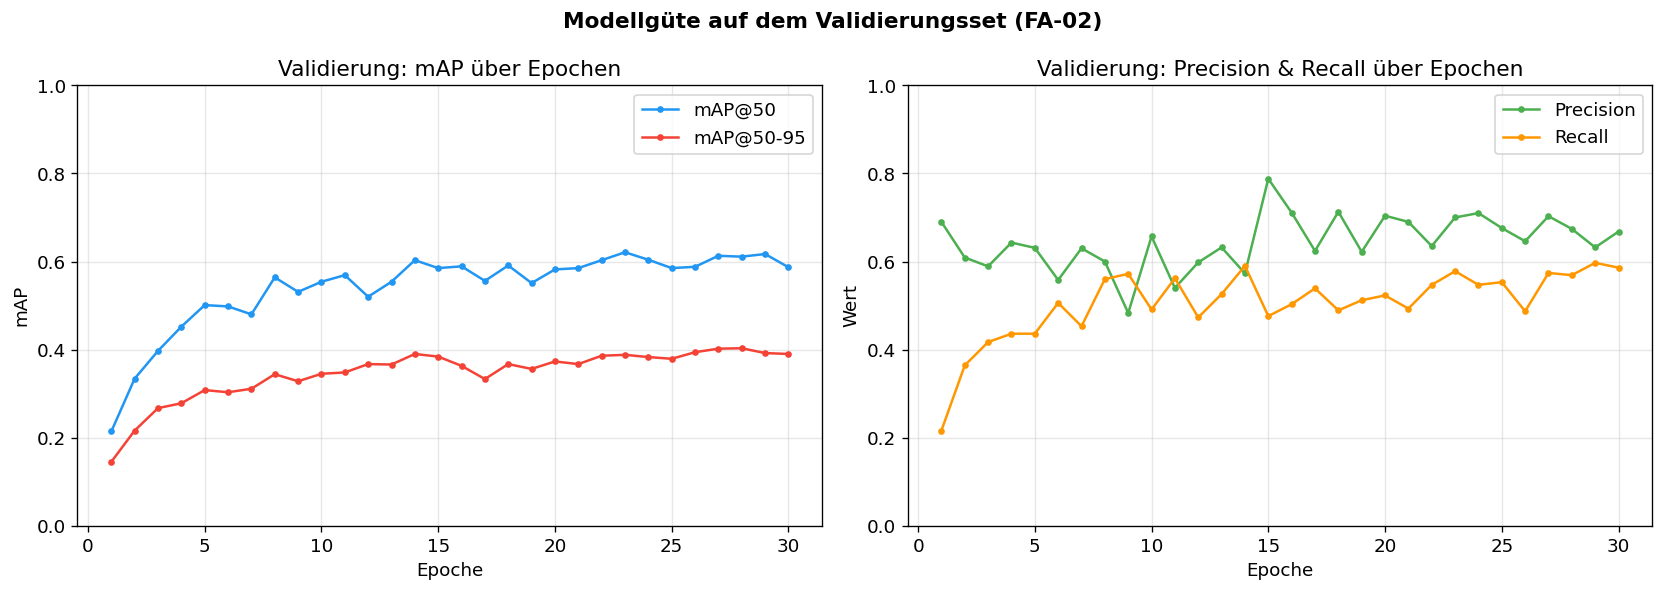

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# mAP-Kurven
axes[0].plot(training_df['epoch'], training_df['mAP50'], marker='.', label='mAP@50', color='#2196F3', linewidth=1.5)
axes[0].plot(training_df['epoch'], training_df['mAP50_95'], marker='.', label='mAP@50-95', color='#F44336', linewidth=1.5)
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('mAP')
axes[0].set_title('Validierung: mAP über Epochen')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Precision / Recall
axes[1].plot(training_df['epoch'], training_df['Precision'], marker='.', label='Precision', color='#4CAF50', linewidth=1.5)
axes[1].plot(training_df['epoch'], training_df['Recall'], marker='.', label='Recall', color='#FF9800', linewidth=1.5)
axes[1].set_xlabel('Epoche')
axes[1].set_ylabel('Wert')
axes[1].set_title('Validierung: Precision & Recall über Epochen')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.suptitle('Modellgüte auf dem Validierungsset (FA-02)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_validation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Checkpoint-Selektion und Best-Epoch (FA-02)

In [7]:
# Best Epoch nach mAP50-95 (YOLO-Standardkriterium)
best_map50_95 = training_df.loc[training_df['mAP50_95'].idxmax()]
best_map50 = training_df.loc[training_df['mAP50'].idxmax()]

summary = pd.DataFrame([
    {
        'Kriterium': 'Bester mAP@50-95',
        'Epoche': int(best_map50_95['epoch']),
        'mAP@50': round(best_map50_95['mAP50'], 4),
        'mAP@50-95': round(best_map50_95['mAP50_95'], 4),
        'Precision': round(best_map50_95['Precision'], 4),
        'Recall': round(best_map50_95['Recall'], 4),
        'box_loss': round(best_map50_95['box_loss'], 4),
        'cls_loss': round(best_map50_95['cls_loss'], 4),
        'dfl_loss': round(best_map50_95['dfl_loss'], 4),
    },
    {
        'Kriterium': 'Bester mAP@50',
        'Epoche': int(best_map50['epoch']),
        'mAP@50': round(best_map50['mAP50'], 4),
        'mAP@50-95': round(best_map50['mAP50_95'], 4),
        'Precision': round(best_map50['Precision'], 4),
        'Recall': round(best_map50['Recall'], 4),
        'box_loss': round(best_map50['box_loss'], 4),
        'cls_loss': round(best_map50['cls_loss'], 4),
        'dfl_loss': round(best_map50['dfl_loss'], 4),
    },
    {
        'Kriterium': 'Letzte Epoche',
        'Epoche': int(training_df['epoch'].iloc[-1]),
        'mAP@50': round(training_df['mAP50'].iloc[-1], 4),
        'mAP@50-95': round(training_df['mAP50_95'].iloc[-1], 4),
        'Precision': round(training_df['Precision'].iloc[-1], 4),
        'Recall': round(training_df['Recall'].iloc[-1], 4),
        'box_loss': round(training_df['box_loss'].iloc[-1], 4),
        'cls_loss': round(training_df['cls_loss'].iloc[-1], 4),
        'dfl_loss': round(training_df['dfl_loss'].iloc[-1], 4),
    },
]).set_index('Kriterium')

display(summary.style.format(precision=4).set_caption(
    "Tabelle: Checkpoint-Selektion (FA-02)"))

print(f"\n-> Empfohlener Checkpoint: Epoche {int(best_map50_95['epoch'])} "
      f"(best mAP@50-95 = {best_map50_95['mAP50_95']:.4f})")

,Epoche,mAP@50,mAP@50-95,Precision,Recall,box_loss,cls_loss,dfl_loss
Kriterium,,,,,,,,
Bester mAP@50-95,28,0.6110,0.4030,0.6740,0.5690,1.0130,1.0510,1.0640
Bester mAP@50,23,0.6210,0.3880,0.7000,0.5780,1.0370,1.1420,1.0890
Letzte Epoche,30,0.5870,0.3900,0.6680,0.5860,0.9711,0.9807,1.0410



-> Empfohlener Checkpoint: Epoche 28 (best mAP@50-95 = 0.4030)


### 2.5 Precision/Recall pro Klasse (FA-03)

> **Hinweis:** Die Pro-Klasse-Metriken stammen aus dem YOLO-Validierungslauf (`val.py`) und werden
> aus einer separaten Datei eingelesen (z. B. `results_per_class.csv`).  
> Falls diese Datei noch nicht vorliegt, kann der Validierungslauf nachträglich ausgeführt werden:  
> ```python
> from ultralytics import YOLO
> model = YOLO('best.pt')
> results = model.val(data='dataset.yaml', save_json=True, plots=True)
> ```

Pro-Klasse-Metriken geladen: 15 Klassen


,class_name,precision,recall,mAP50,mAP50_95
0,Sitzbank,0.933,1.000,0.995,0.822
1,Grosses_Fahrzeug,0.869,1.000,0.954,0.700
2,Muelltonne,0.608,0.932,0.884,0.690
3,Person,0.703,0.851,0.865,0.659
4,Tisch,0.460,1.000,0.912,0.648
5,Hund,0.953,0.667,0.912,0.529
6,Auto,0.636,0.673,0.694,0.481
7,Baustellenhindernis,0.887,0.500,0.724,0.420
8,Zaun_Absperrung,0.467,0.381,0.365,0.263
9,Ampel,0.544,0.333,0.407,0.260


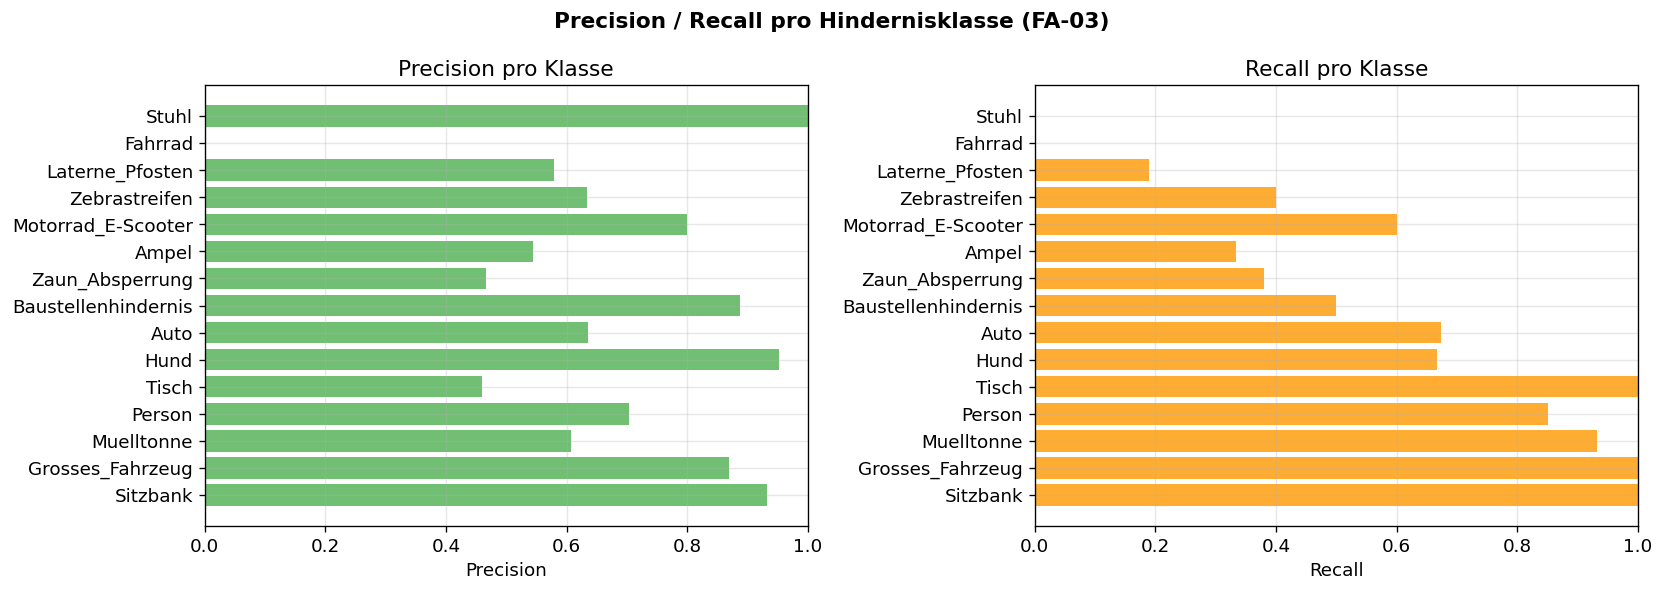

In [8]:
# ── Pro-Klasse-Metriken einlesen ────────────────────────────────────
PER_CLASS_CSV = "results_per_class.csv"  # Pfad anpassen

try:
    pc_df = pd.read_csv(PER_CLASS_CSV)
    print(f"Pro-Klasse-Metriken geladen: {len(pc_df)} Klassen")
    display(pc_df.style.format(precision=3).set_caption(
        "Tabelle: Precision / Recall pro Klasse (FA-03)"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    y_pos = np.arange(len(pc_df))
    class_col = 'class_name' if 'class_name' in pc_df.columns else pc_df.columns[0]

    axes[0].barh(y_pos, pc_df['precision'], color='#4CAF50', alpha=0.8)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(pc_df[class_col])
    axes[0].set_xlabel('Precision')
    axes[0].set_title('Precision pro Klasse')
    axes[0].set_xlim(0, 1)

    axes[1].barh(y_pos, pc_df['recall'], color='#FF9800', alpha=0.8)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(pc_df[class_col])
    axes[1].set_xlabel('Recall')
    axes[1].set_title('Recall pro Klasse')
    axes[1].set_xlim(0, 1)

    plt.suptitle('Precision / Recall pro Hindernisklasse (FA-03)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_per_class_precision_recall.png', dpi=150, bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print(f"Datei '{PER_CLASS_CSV}' nicht gefunden.")
    print("  Bitte den YOLO-Validierungslauf ausfuehren und die Pro-Klasse-Ergebnisse als CSV bereitstellen.")
    print("  Erwartete Spalten: class_name, precision, recall, mAP50, mAP50_95")

### 2.6 label_pretty- und label_raw-Verteilung in Warnungen (FA-03)

Prüfung, welche der 15 trainierten Klassen im Feldbetrieb tatsächlich erkannt und als Warnung ausgegeben wurden.

In [9]:
# ── Klassenabdeckung im Feldbetrieb ────────────────────────────────
ALL_CLASSES = [
    'Ampel', 'Auto', 'Baustellenhindernis', 'Fahrrad',
    'Grosses_Fahrzeug', 'Hund', 'Laterne_Pfosten',
    'Motorrad_E-Scooter', 'Muelltonne', 'Person',
    'Sitzbank', 'Stuhl', 'Tisch', 'Zaun_Absperrung', 'Zebrastreifen'
]  

all_we_ds = pd.concat([ds_agg[s]['we'] for s in ds_agg if len(ds_agg[s]['we']) > 0], ignore_index=True)

raw_counts = all_we_ds['label_raw'].value_counts()
has_pretty = 'label_pretty' in all_we_ds.columns

rows = []
for cls in sorted(raw_counts.index):
    row = {
        'Klasse (label_raw)': cls,
        'Warnungen': int(raw_counts.get(cls, 0)),
        'Anteil (%)': round(raw_counts.get(cls, 0) / len(all_we_ds) * 100, 1),
    }
    if has_pretty:
        match = all_we_ds.loc[all_we_ds['label_raw'] == cls, 'label_pretty']
        row['label_pretty'] = match.mode().iloc[0] if len(match) > 0 else '-'
    rows.append(row)

class_coverage_df = pd.DataFrame(rows)
display(class_coverage_df.style.format(precision=1).set_caption(
    "Tabelle: Klassenverteilung im Feldbetrieb (FA-03)"))

detected_classes = set(raw_counts.index)
print(f"\nIm Feldbetrieb erkannte Klassen: {len(detected_classes)} von {len(ALL_CLASSES)} definierten Klassen")
missing = set(ALL_CLASSES) - detected_classes
if missing:
    print(f"Nicht erkannte Klassen: {', '.join(sorted(missing))}")
else:
    print("Alle definierten Klassen wurden mindestens einmal erkannt.")

if has_pretty:
    print("\nlabel_pretty-Spalte vorhanden.")
else:
    print("\nlabel_pretty-Spalte nicht in warn_events vorhanden - nur label_raw verfuegbar.")

,Klasse (label_raw),Warnungen,Anteil (%),label_pretty
0,Auto,96,24.0,Auto
1,Baustellenhindernis,37,9.2,Baustellenhindernis
2,Fahrrad,30,7.5,Fahrrad
3,Grosses_Fahrzeug,52,13.0,Grosses Fahrzeug
4,Motorrad_E-Scooter,2,0.5,Motorrad E / Scooter
5,Person,182,45.5,Person
6,Zebrastreifen,1,0.2,Zebrastreifen



Im Feldbetrieb erkannte Klassen: 7 von 15 definierten Klassen
Nicht erkannte Klassen: Ampel, Hund, Laterne_Pfosten, Muelltonne, Sitzbank, Stuhl, Tisch, Zaun_Absperrung

label_pretty-Spalte vorhanden.


### 2.7 Warnrate nach Klasse (FA-03)

In [10]:
rows = []
for s in ['S1', 'S2', 'S3']:
    if s not in ds_agg or len(ds_agg[s]['we']) == 0:
        continue
    we = ds_agg[s]['we']
    dur = ds_agg[s]['duration_s']
    class_counts = we['label_raw'].value_counts()
    for cls, cnt in class_counts.items():
        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'Klasse': cls,
            'Anzahl': cnt,
            'Warn/min': round(cnt / max(1, dur) * 60, 2),
        })

warn_per_class = pd.DataFrame(rows)
pivot = warn_per_class.pivot_table(index='Klasse', columns='Szenario', values='Warn/min', fill_value=0)
display(pivot.style.format(precision=2).set_caption(
    "Tabelle: Warnrate pro Klasse und Szenario (Warn/min) – FA-03"))

Szenario,S1: Wohngebiet,S2: Stadtzentrum,S3: Fußgängerzone
Klasse,,,
Auto,6.66,3.40,0.13
Baustellenhindernis,1.77,1.43,0.89
Fahrrad,0.00,2.41,1.01
Grosses_Fahrzeug,4.68,0.77,0.00
Motorrad_E-Scooter,0.00,0.22,0.00
Person,0.73,5.71,15.60
Zebrastreifen,0.00,0.00,0.13


## 3. Pipeline-Performance (FA-01 / NFA-01 / NFA-02)

### 3.1 Laufzeitmetriken pro Szenario

In [11]:
def pipeline_table(agg_dict, label=""):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        fm = agg_dict[s]['fm']
        dur = agg_dict[s]['duration_s']
        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'Frames': len(fm),
            'Dauer (s)': f"{dur:.0f}",
            'fps mean': round(fm['fps'].mean(), 1),
            'fps p50': round(fm['fps'].median(), 1),
            'fps p90': round(fm['fps'].quantile(0.9), 1),
            'fps min': round(fm['fps'].min(), 1),
            'fps max': round(fm['fps'].max(), 1),
            'e2e mean': round(fm['e2e_ms'].mean(), 0),
            'e2e p50': round(fm['e2e_ms'].median(), 0),
            'e2e p90': round(fm['e2e_ms'].quantile(0.9), 0),
            'e2e min': round(fm['e2e_ms'].min(), 0),
            'e2e max': round(fm['e2e_ms'].max(), 0),
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(pipeline_table(ds_agg).style.format(precision=2).set_caption(
    "Tabelle: Bildrate und End-to-End-Latenz pro Szenario (DangerScore) – FA-01 / NFA-01"))

,Frames,Dauer (s),fps mean,fps p50,fps p90,fps min,fps max,e2e mean,e2e p50,e2e p90,e2e min,e2e max
Szenario,,,,,,,,,,,,
S1: Wohngebiet,3735,577,6.50,6.70,6.80,3.30,7.00,153.00,148.00,161.00,141.00,301.00
S2: Stadtzentrum,2985,547,5.70,6.10,6.70,0.10,7.00,179.00,163.00,212.00,141.00,2994.00
S3: Fußgängerzone,2475,473,6.10,6.30,6.80,0.00,7.10,166.00,157.00,203.00,140.00,2476.00


In [12]:
def pipeline_table(agg_dict, label=""):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        fm = agg_dict[s]['fm']
        dur = agg_dict[s]['duration_s']
        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'Frames': len(fm),
            'Dauer (s)': f"{dur:.0f}",
            'fps mean': round(fm['fps'].mean(), 1),
            'fps p50': round(fm['fps'].median(), 1),
            'fps p90': round(fm['fps'].quantile(0.9), 1),
            'fps min': round(fm['fps'].min(), 1),
            'fps max': round(fm['fps'].max(), 1),
            'e2e mean': round(fm['e2e_ms'].mean(), 0),
            'e2e p50': round(fm['e2e_ms'].median(), 0),
            'e2e p90': round(fm['e2e_ms'].quantile(0.9), 0),
            'e2e min': round(fm['e2e_ms'].min(), 0),
            'e2e max': round(fm['e2e_ms'].max(), 0),
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(pipeline_table(co_agg).style.format(precision=2).set_caption(
    "Tabelle: Bildrate und End-to-End-Latenz pro Szenario (Confidence-Only) – FA-01 / NFA-01"))

,Frames,Dauer (s),fps mean,fps p50,fps p90,fps min,fps max,e2e mean,e2e p50,e2e p90,e2e min,e2e max
Szenario,,,,,,,,,,,,
S1: Wohngebiet,3675,564,6.60,6.70,6.90,3.40,7.00,152.00,147.00,157.00,141.00,295.00
S2: Stadtzentrum,3225,576,5.70,6.10,6.60,2.50,7.00,177.00,163.00,211.00,142.00,397.00
S3: Fußgängerzone,2565,486,6.00,6.20,6.80,0.00,6.90,170.00,158.00,211.00,142.00,2208.00


### 3.2 Teilzeiten der Verarbeitungspipeline (NFA-02)

In [13]:
def teilzeiten_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        fm = agg_dict[s]['fm']
        for col, label in [('pre_ms', 'Vorverarbeitung'), ('inf_ms', 'Inferenz'), ('post_ms', 'Nachverarbeitung')]:
            rows.append({
                'Szenario': SCENARIO_LABELS[s],
                'Phase': label,
                'mean (ms)': round(fm[col].mean(), 1),
                'p50 (ms)': round(fm[col].median(), 1),
                'p90 (ms)': round(fm[col].quantile(0.9), 1),
            })
    df = pd.DataFrame(rows)
    return df

display(teilzeiten_table(ds_agg).style.format(precision=2).set_caption("Tabelle: Teilzeiten der Pipeline pro Szenario").hide(axis='index'))

Szenario,Phase,mean (ms),p50 (ms),p90 (ms)
S1: Wohngebiet,Vorverarbeitung,46.50,46.20,49.20
S1: Wohngebiet,Inferenz,103.70,98.60,109.00
S1: Wohngebiet,Nachverarbeitung,2.80,2.70,3.00
S2: Stadtzentrum,Vorverarbeitung,55.30,52.60,68.70
S2: Stadtzentrum,Inferenz,120.60,106.70,147.40
S2: Stadtzentrum,Nachverarbeitung,3.60,3.50,4.30
S3: Fußgängerzone,Vorverarbeitung,49.80,49.20,55.50
S3: Fußgängerzone,Inferenz,112.80,103.90,147.70
S3: Fußgängerzone,Nachverarbeitung,3.30,3.10,3.80


### 3.3 Stabilitätsmetriken (FA-01 / NFA-01 / NFA-02 / NFA-05)

In [14]:
def stability_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        fm = agg_dict[s]['fm']
        n = len(fm)
        stalls = fm['is_stall'].sum()
        cam_fps_vals = fm['cam_fps'][fm['cam_fps'] > 0]
        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'cam_fps mean': round(cam_fps_vals.mean(), 1) if len(cam_fps_vals) > 0 else 'n/a',
            'cam_fps p50': round(cam_fps_vals.median(), 1) if len(cam_fps_vals) > 0 else 'n/a',
            'cam_fps p90': round(cam_fps_vals.quantile(0.9), 1) if len(cam_fps_vals) > 0 else 'n/a',
            'drop_rate mean (%)': round(fm['drop_rate_pct'].mean(), 1),
            'drop_rate p50 (%)': round(fm['drop_rate_pct'].median(), 1),
            'drop_rate p90 (%)': round(fm['drop_rate_pct'].quantile(0.9), 1),
            'dropped_frames sum': int(fm['dropped_frames_est'].sum()),
            'dropped_frames rate (%)': round(fm['dropped_frames_est'].sum() / max(1, n) * 100, 2),
            'Stalls': int(stalls),
            'Stall-Rate (%)': round(stalls / n * 100, 2),
            'det_count mean': round(fm['det_count'].mean(), 1),
            'det_count p50': int(fm['det_count'].median()),
            'det_count p90': int(fm['det_count'].quantile(0.9)),
            'det_count max': int(fm['det_count'].max()),
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(stability_table(ds_agg).style.format(precision=2).set_caption(
    "Tabelle: Stabilitaetsmetriken pro Szenario – FA-01 / NFA-01 / NFA-02 / NFA-05"))

,cam_fps mean,cam_fps p50,cam_fps p90,drop_rate mean (%),drop_rate p50 (%),drop_rate p90 (%),dropped_frames sum,dropped_frames rate (%),Stalls,Stall-Rate (%),det_count mean,det_count p50,det_count p90,det_count max
Szenario,,,,,,,,,,,,,,
S1: Wohngebiet,6.50,6.50,6.60,2.30,0.00,4.20,0,0.00,0,0.00,1.20,1,2,6
S2: Stadtzentrum,6.10,6.10,6.40,7.60,1.40,20.40,18212,610.12,2,0.07,2.00,2,4,10
S3: Fußgängerzone,6.20,6.20,6.30,4.30,0.00,21.20,491,19.84,2,0.08,6.30,6,9,13


In [15]:
def stability_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        fm = agg_dict[s]['fm']
        n = len(fm)
        stalls = fm['is_stall'].sum()
        cam_fps_vals = fm['cam_fps'][fm['cam_fps'] > 0]
        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'cam_fps p50': round(cam_fps_vals.median(), 1) if len(cam_fps_vals) > 0 else 'n/a',
            'drop_rate mean (%)': round(fm['drop_rate_pct'].mean(), 1),
            'drop_rate p90 (%)': round(fm['drop_rate_pct'].quantile(0.9), 1),
            'Stalls': int(stalls),
            'Stall-Rate (%)': round(stalls / n * 100, 2),
            'det_count p50': int(fm['det_count'].median()),
            'det_count max': int(fm['det_count'].max()),
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(stability_table(ds_agg).style.format(precision=2).set_caption(
    "Tabelle: Stabilitaetsmetriken pro Szenario – FA-01 / NFA-01 / NFA-02 / NFA-05"))

,cam_fps p50,drop_rate mean (%),drop_rate p90 (%),Stalls,Stall-Rate (%),det_count p50,det_count max
Szenario,,,,,,,
S1: Wohngebiet,6.50,2.30,4.20,0,0.00,1,6
S2: Stadtzentrum,6.10,7.60,20.40,2,0.07,2,10
S3: Fußgängerzone,6.20,4.30,21.20,2,0.08,6,13


### 3.4 Visualisierung: FPS und E2E-Latenz

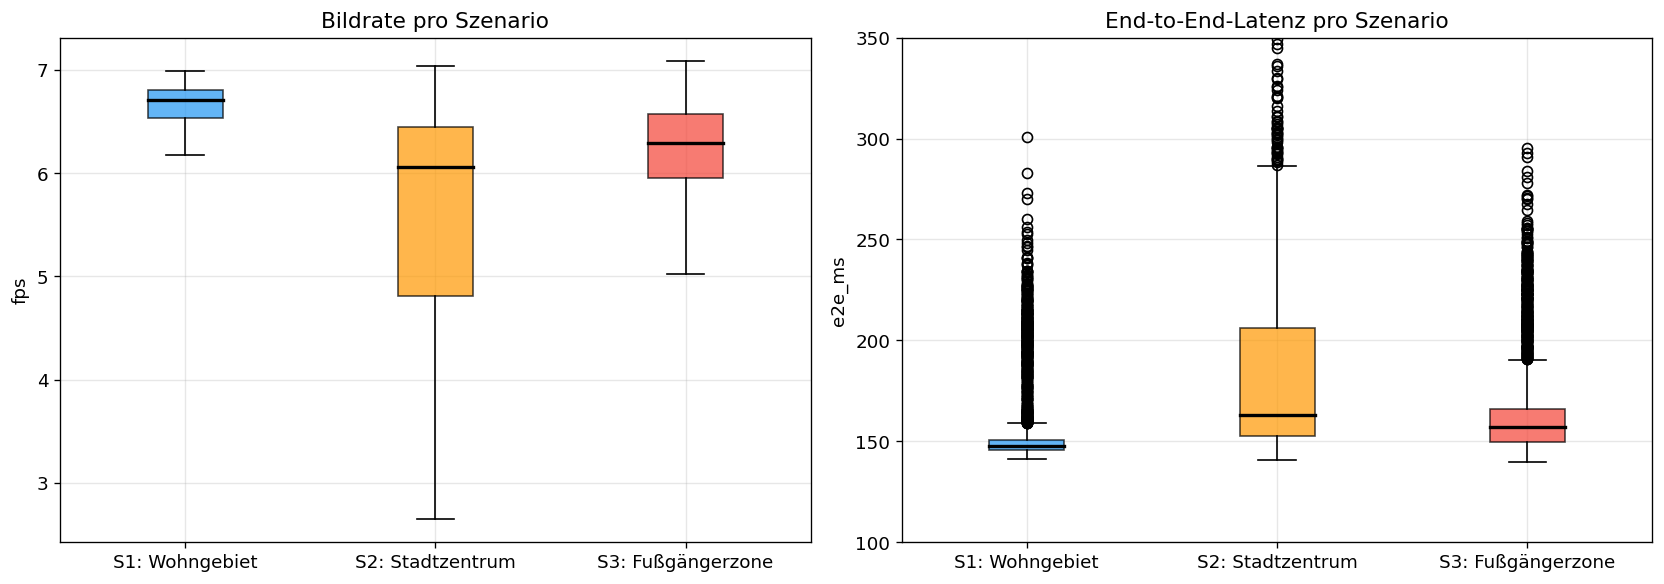

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FPS Boxplot
fps_data = [ds_agg[s]['fm']['fps'] for s in ['S1', 'S2', 'S3'] if s in ds_agg]
bp1 = axes[0].boxplot(fps_data, labels=[SCENARIO_LABELS[s] for s in ['S1', 'S2', 'S3'] if s in ds_agg],
                       patch_artist=True, showfliers=False, medianprops=dict(color='black', linewidth=2))
for patch, s in zip(bp1['boxes'], ['S1', 'S2', 'S3']):
    patch.set_facecolor(COLORS[s])
    patch.set_alpha(0.7)
axes[0].set_ylabel('fps')
axes[0].set_title('Bildrate pro Szenario')

# E2E Boxplot
e2e_data = [ds_agg[s]['fm']['e2e_ms'] for s in ['S1', 'S2', 'S3'] if s in ds_agg]
bp2 = axes[1].boxplot(e2e_data, labels=[SCENARIO_LABELS[s] for s in ['S1', 'S2', 'S3'] if s in ds_agg],
                       patch_artist=True, showfliers=True, medianprops=dict(color='black', linewidth=2))
for patch, s in zip(bp2['boxes'], ['S1', 'S2', 'S3']):
    patch.set_facecolor(COLORS[s])
    patch.set_alpha(0.7)
axes[1].set_ylabel('e2e_ms')
axes[1].set_title('End-to-End-Latenz pro Szenario')
axes[1].set_ylim(100, 350)  # Outlier > 2000ms abschneiden für Lesbarkeit

plt.tight_layout()
plt.savefig('fig_fps_e2e_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Visualisierung: Anteil der Pipeline-Phasen (NFA-02)

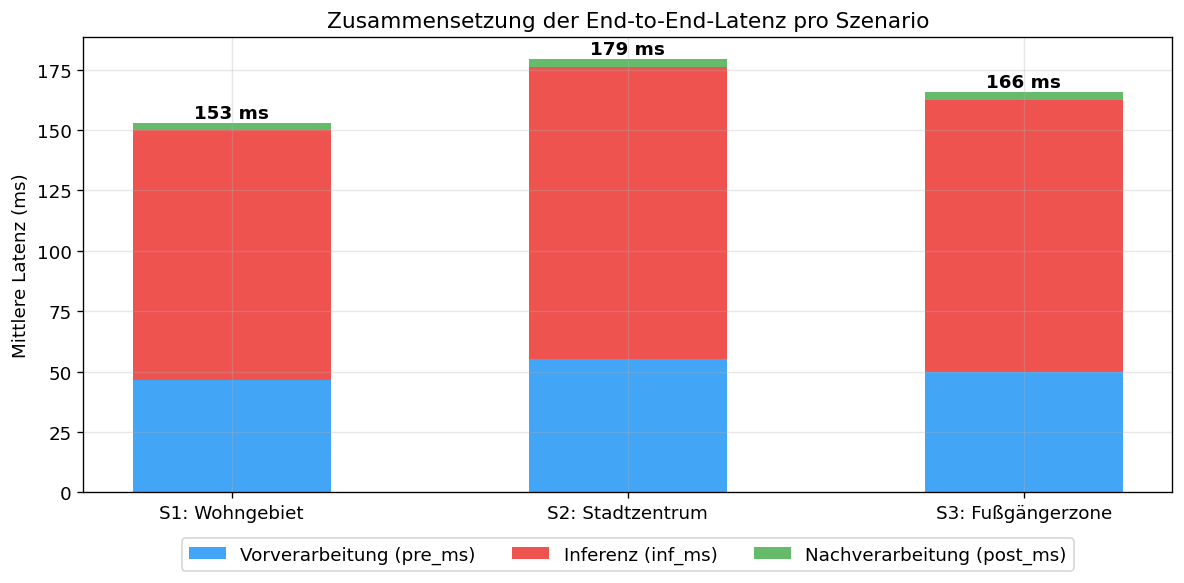

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
scenarios = [s for s in ['S1', 'S2', 'S3'] if s in ds_agg]
x = np.arange(len(scenarios))
width = 0.5

pre_vals =  [ds_agg[s]['fm']['pre_ms'].mean() for s in scenarios]
inf_vals =  [ds_agg[s]['fm']['inf_ms'].mean() for s in scenarios]
post_vals = [ds_agg[s]['fm']['post_ms'].mean() for s in scenarios]

bars_pre = ax.bar(x, pre_vals, width, label='Vorverarbeitung (pre_ms)', color='#42A5F5')
bars_inf = ax.bar(x, inf_vals, width, bottom=pre_vals, label='Inferenz (inf_ms)', color='#EF5350')
bars_post = ax.bar(x, post_vals, width, bottom=[p+i for p,i in zip(pre_vals, inf_vals)], label='Nachverarbeitung (post_ms)', color='#66BB6A')

ax.set_ylabel('Mittlere Latenz (ms)')
ax.set_title('Zusammensetzung der End-to-End-Latenz pro Szenario')
ax.set_xticks(x)
ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3)

for i, s in enumerate(scenarios):
    total = pre_vals[i] + inf_vals[i] + post_vals[i]
    ax.text(i, total + 2, f'{total:.0f} ms', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_pipeline_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Robustheits- und Korrelationsanalyse (NFA-05)

### 4.1 Korrelation: det_count und e2e_ms

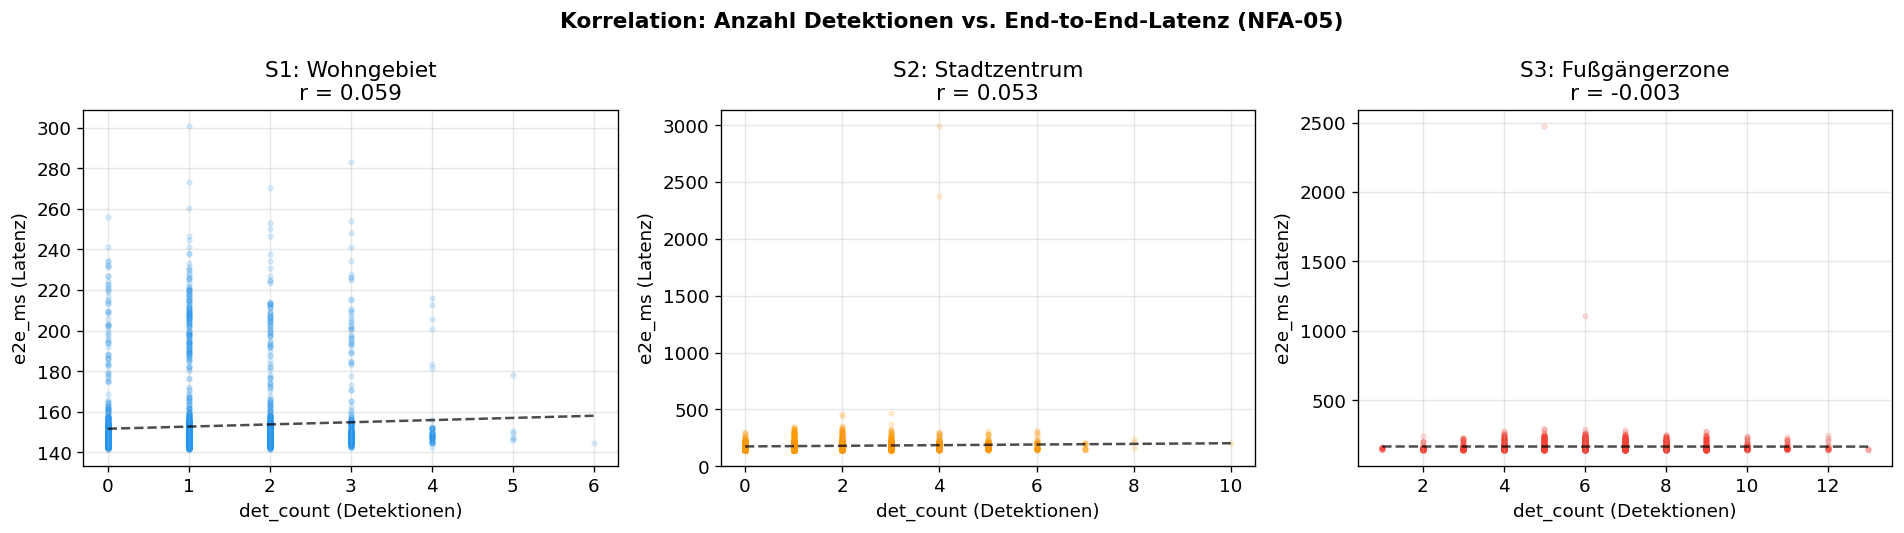

,Pearson r,Spearman rho,det_count mean,e2e_ms mean
Szenario,,,,
S1: Wohngebiet,0.0591,0.0646,1.2000,152.9000
S2: Stadtzentrum,0.0529,0.0412,2.0000,179.5000
S3: Fußgängerzone,-0.0028,0.0441,6.3000,165.9000


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, s in enumerate(['S1', 'S2', 'S3']):
    if s not in ds_agg:
        continue
    fm = ds_agg[s]['fm']
    axes[i].scatter(fm['det_count'], fm['e2e_ms'], alpha=0.15, s=8, color=COLORS[s])

    corr = fm['det_count'].corr(fm['e2e_ms'])
    axes[i].set_xlabel('det_count (Detektionen)')
    axes[i].set_ylabel('e2e_ms (Latenz)')
    axes[i].set_title(f'{SCENARIO_LABELS[s]}\nr = {corr:.3f}')

    if len(fm) > 2:
        z = np.polyfit(fm['det_count'], fm['e2e_ms'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(fm['det_count'].min(), fm['det_count'].max(), 50)
        axes[i].plot(x_range, p(x_range), '--', color='black', linewidth=1.5, alpha=0.7)

plt.suptitle('Korrelation: Anzahl Detektionen vs. End-to-End-Latenz (NFA-05)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_det_e2e.png', dpi=150, bbox_inches='tight')
plt.show()

corr_rows = []
for s in ['S1', 'S2', 'S3']:
    if s not in ds_agg:
        continue
    fm = ds_agg[s]['fm']
    corr_rows.append({
        'Szenario': SCENARIO_LABELS[s],
        'Pearson r': round(fm['det_count'].corr(fm['e2e_ms']), 4),
        'Spearman rho': round(fm['det_count'].corr(fm['e2e_ms'], method='spearman'), 4),
        'det_count mean': round(fm['det_count'].mean(), 1),
        'e2e_ms mean': round(fm['e2e_ms'].mean(), 1),
    })
display(pd.DataFrame(corr_rows).set_index('Szenario').style.format(precision=4).set_caption(
    "Tabelle: Korrelation det_count vs. e2e_ms (NFA-05)"))

## 5. Warnlogik-Analyse (FA-04 – FA-10)

### 5.1 Warnrate und Klassenverteilung (FA-07)

In [19]:
def warn_overview_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        we = agg_dict[s]['we']
        dur = agg_dict[s]['duration_s']
        n = len(we)
        if n == 0:
            continue
        warn_rate = n / max(1, dur) * 60
        classes = we['label_raw'].value_counts()
        top3 = ', '.join([f"{cls} ({cnt})" for cls, cnt in classes.head(3).items()])

        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'Warnungen': n,
            'Warn/min': round(warn_rate, 1),
            'Klassen': we['label_raw'].nunique(),
            'Top-3 Klassen': top3,
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(warn_overview_table(ds_agg).style.format(precision=2).set_caption("Tabelle: Warnrate und Klassenverteilung pro Szenario"))

,Warnungen,Warn/min,Klassen,Top-3 Klassen
Szenario,,,,
S1: Wohngebiet,133,13.80,4,"Auto (64), Grosses_Fahrzeug (45), Baustellenhindernis (17)"
S2: Stadtzentrum,127,13.90,6,"Person (52), Auto (31), Fahrrad (22)"
S3: Fußgängerzone,140,17.80,5,"Person (123), Fahrrad (8), Baustellenhindernis (7)"


### 5.2 Klassenverteilung pro Szenario (FA-03)

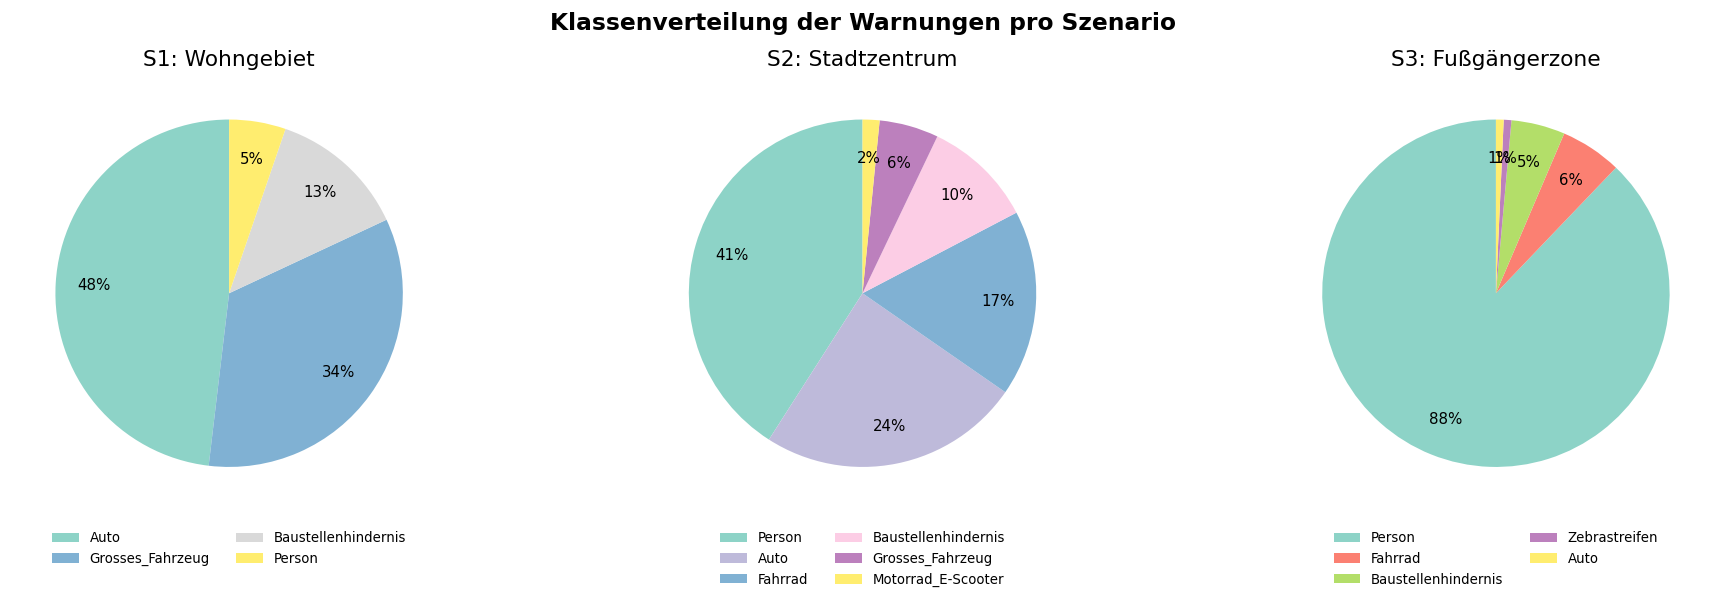

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, s in enumerate(['S1', 'S2', 'S3']):
    if s not in ds_agg or len(ds_agg[s]['we']) == 0:
        continue
    we = ds_agg[s]['we']
    counts = we['label_raw'].value_counts()
    colors_list = plt.cm.Set3(np.linspace(0, 1, len(counts)))

    wedges, _, autotexts = axes[i].pie(
        counts.values, autopct='%1.0f%%',
        colors=colors_list, pctdistance=0.78, startangle=90,
        textprops={'fontsize': 9}
    )
    axes[i].legend(wedges, counts.index, loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=8, ncol=2, frameon=False)
    axes[i].set_title(SCENARIO_LABELS[s])

plt.suptitle('Klassenverteilung der Warnungen pro Szenario', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Zonenzuordnung (FA-04)

In [21]:
def zone_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        we = agg_dict[s]['we']
        n = len(we)
        if n == 0:
            continue
        zones = we['zone'].value_counts()
        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'LEFT': f"{zones.get('LEFT', 0)} ({zones.get('LEFT', 0)/n*100:.0f}%)",
            'MID': f"{zones.get('MID', 0)} ({zones.get('MID', 0)/n*100:.0f}%)",
            'RIGHT': f"{zones.get('RIGHT', 0)} ({zones.get('RIGHT', 0)/n*100:.0f}%)",
            'MID-Anteil (%)': round(zones.get('MID', 0) / n * 100, 1),
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(zone_table(ds_agg).style.format(precision=2).set_caption("Tabelle: Zonenzuordnung der Warnungen"))

,LEFT,MID,RIGHT,MID-Anteil (%)
Szenario,,,,
S1: Wohngebiet,29 (22%),11 (8%),93 (70%),8.30
S2: Stadtzentrum,79 (62%),28 (22%),20 (16%),22.00
S3: Fußgängerzone,46 (33%),55 (39%),39 (28%),39.30


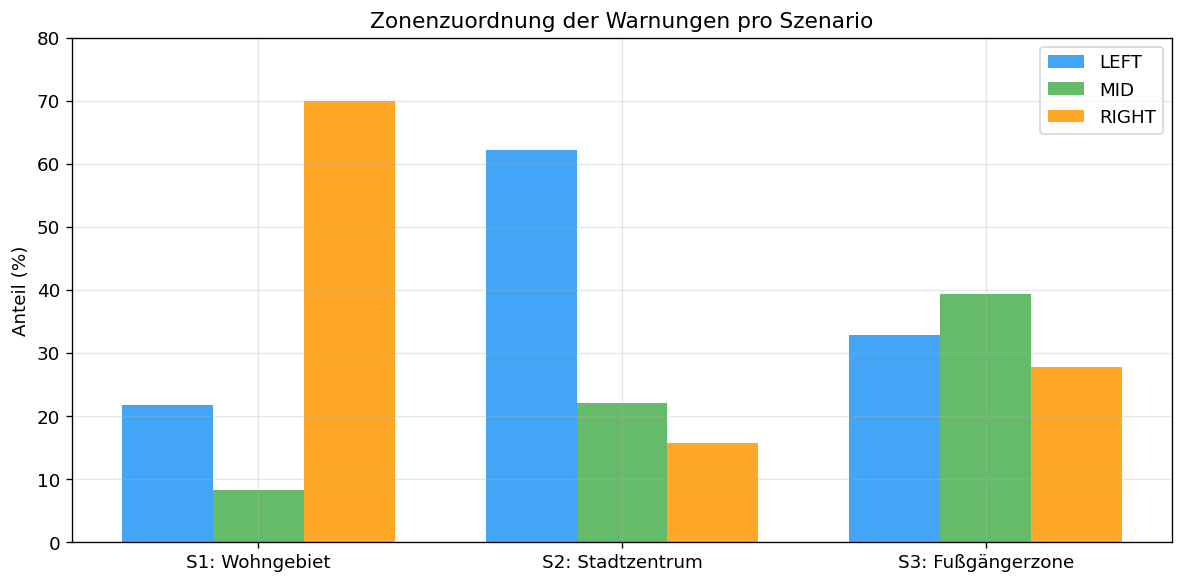

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
scenarios = [s for s in ['S1', 'S2', 'S3'] if s in ds_agg]
x = np.arange(len(scenarios))
width = 0.25

for i, zone in enumerate(['LEFT', 'MID', 'RIGHT']):
    vals = []
    for s in scenarios:
        we = ds_agg[s]['we']
        n = len(we)
        vals.append(we['zone'].value_counts().get(zone, 0) / max(1, n) * 100)
    color = {'LEFT': '#42A5F5', 'MID': '#66BB6A', 'RIGHT': '#FFA726'}[zone]
    ax.bar(x + i * width, vals, width, label=zone, color=color)

ax.set_ylabel('Anteil (%)')
ax.set_title('Zonenzuordnung der Warnungen pro Szenario')
ax.set_xticks(x + width)
ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios])
ax.legend()
ax.set_ylim(0, 80)

plt.tight_layout()
plt.savefig('fig_zone_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Proximity-Verteilung (FA-05)

In [23]:
def proximity_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        we = agg_dict[s]['we']
        n = len(we)
        if n == 0:
            continue
        prox = we['proximity'].value_counts()
        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'FAR': f"{prox.get('FAR', 0)} ({prox.get('FAR', 0)/n*100:.0f}%)",
            'NEAR': f"{prox.get('NEAR', 0)} ({prox.get('NEAR', 0)/n*100:.0f}%)",
            'IMMEDIATE': f"{prox.get('IMMEDIATE', 0)} ({prox.get('IMMEDIATE', 0)/n*100:.0f}%)",
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(proximity_table(ds_agg).style.set_caption("Tabelle: Proximity-Verteilung der Warnungen"))

,FAR,NEAR,IMMEDIATE
Szenario,,,
S1: Wohngebiet,66 (50%),39 (29%),28 (21%)
S2: Stadtzentrum,80 (63%),26 (20%),21 (17%)
S3: Fußgängerzone,70 (50%),26 (19%),44 (31%)


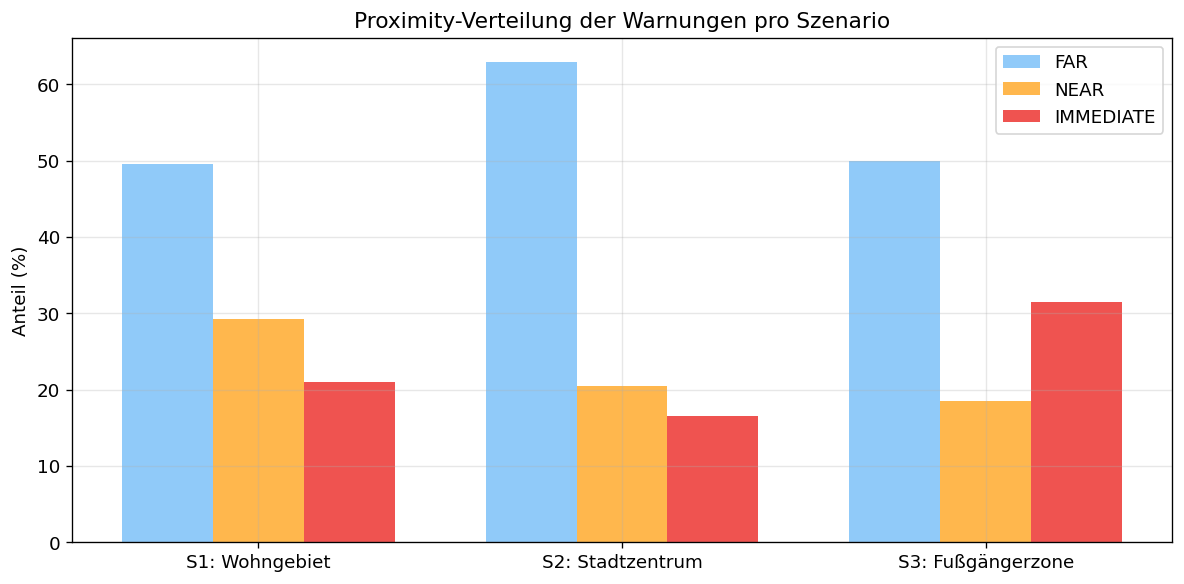

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
scenarios = [s for s in ['S1', 'S2', 'S3'] if s in ds_agg]
x = np.arange(len(scenarios))
width = 0.25

for i, prox in enumerate(['FAR', 'NEAR', 'IMMEDIATE']):
    vals = []
    for s in scenarios:
        we = ds_agg[s]['we']
        n = len(we)
        vals.append(we['proximity'].value_counts().get(prox, 0) / max(1, n) * 100)
    color = {'FAR': '#90CAF9', 'NEAR': '#FFB74D', 'IMMEDIATE': '#EF5350'}[prox]
    ax.bar(x + i * width, vals, width, label=prox, color=color)

ax.set_ylabel('Anteil (%)')
ax.set_title('Proximity-Verteilung der Warnungen pro Szenario')
ax.set_xticks(x + width)
ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios])
ax.legend()

plt.tight_layout()
plt.savefig('fig_proximity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4b Warnrate nach Proximity-Stufe (FA-05)

In [25]:
def proximity_warnrate_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        we = agg_dict[s]['we']
        dur = agg_dict[s]['duration_s']
        n = len(we)
        if n == 0:
            continue
        prox = we['proximity'].value_counts()
        for p in ['FAR', 'NEAR', 'IMMEDIATE']:
            cnt = prox.get(p, 0)
            rows.append({
                'Szenario': SCENARIO_LABELS[s],
                'Proximity': p,
                'Anzahl': cnt,
                'Anteil (%)': round(cnt / n * 100, 1),
                'Warn/min': round(cnt / max(1, dur) * 60, 2),
            })
    return pd.DataFrame(rows)

display(proximity_warnrate_table(ds_agg).style.format(precision=2).set_caption(
    "Tabelle: Warnrate pro Proximity-Stufe und Szenario (FA-05)").hide(axis='index'))

Szenario,Proximity,Anzahl,Anteil (%),Warn/min
S1: Wohngebiet,FAR,66,49.60,6.87
S1: Wohngebiet,NEAR,39,29.30,4.06
S1: Wohngebiet,IMMEDIATE,28,21.10,2.91
S2: Stadtzentrum,FAR,80,63.00,8.78
S2: Stadtzentrum,NEAR,26,20.50,2.85
S2: Stadtzentrum,IMMEDIATE,21,16.50,2.31
S3: Fußgängerzone,FAR,70,50.00,8.88
S3: Fußgängerzone,NEAR,26,18.60,3.30
S3: Fußgängerzone,IMMEDIATE,44,31.40,5.58


### 5.5 DangerScore und Confidence (FA-06)

In [26]:
def score_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        we = agg_dict[s]['we']
        if len(we) == 0:
            continue
        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'DangerScore mean': round(we['danger_score'].mean(), 2),
            'DangerScore p50': round(we['danger_score'].median(), 2),
            'DangerScore max': round(we['danger_score'].max(), 2),
            'Confidence mean': round(we['score'].mean(), 2),
            'Confidence p50': round(we['score'].median(), 2),
            'area_ratio mean': round(we['area_ratio'].mean(), 4),
            'area_ratio p50': round(we['area_ratio'].median(), 4),
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(score_table(ds_agg).style.format(precision=2).set_caption("Tabelle: DangerScore, Confidence und Area Ratio zum Warnzeitpunkt"))

,DangerScore mean,DangerScore p50,DangerScore max,Confidence mean,Confidence p50,area_ratio mean,area_ratio p50
Szenario,,,,,,,
S1: Wohngebiet,1.10,1.05,3.14,0.59,0.57,0.10,0.08
S2: Stadtzentrum,1.29,1.33,2.09,0.71,0.76,0.08,0.06
S3: Fußgängerzone,1.61,1.65,3.28,0.84,0.94,0.10,0.06


### 5.5b DangerScore-Gewichtungsparameter (FA-06)

In [27]:
all_we = pd.concat([ds_agg[s]['we'] for s in ds_agg if len(ds_agg[s]['we']) > 0], ignore_index=True)

param_cols = ['class_priority', 'zone_weight', 'k']
available_params = [c for c in param_cols if c in all_we.columns]

if available_params:
    print("Verfuegbare DangerScore-Gewichtungsparameter in warn_events:")
    rows = []
    for col in available_params:
        for s in ['S1', 'S2', 'S3']:
            if s not in ds_agg or len(ds_agg[s]['we']) == 0:
                continue
            we = ds_agg[s]['we']
            if col in we.columns:
                rows.append({
                    'Szenario': SCENARIO_LABELS[s],
                    'Parameter': col,
                    'mean': round(we[col].mean(), 3),
                    'p50': round(we[col].median(), 3),
                    'min': round(we[col].min(), 3),
                    'max': round(we[col].max(), 3),
                })
    if rows:
        display(pd.DataFrame(rows).style.format(precision=3).set_caption(
            "Tabelle: DangerScore-Gewichtungsparameter pro Szenario (FA-06)").hide(axis='index'))
else:
    print("Die Spalten class_priority, zone_weight, k sind nicht in warn_events vorhanden.")
    print("  Diese Parameter sind fest im App-Code definiert und werden nicht pro Warnung geloggt.")
    print("  Dokumentation der festen Werte erfolgt im Implementierungskapitel der Arbeit.")

Verfuegbare DangerScore-Gewichtungsparameter in warn_events:


Szenario,Parameter,mean,p50,min,max
S1: Wohngebiet,class_priority,9.639,10.000,8.000,10.000
S2: Stadtzentrum,class_priority,8.787,8.000,8.000,10.000
S3: Fußgängerzone,class_priority,8.057,8.000,6.000,10.000
S1: Wohngebiet,zone_weight,1.025,1.000,1.000,1.300
S2: Stadtzentrum,zone_weight,1.066,1.000,1.000,1.300
S3: Fußgängerzone,zone_weight,1.118,1.000,1.000,1.300
S1: Wohngebiet,k,2.500,2.500,2.500,2.500
S2: Stadtzentrum,k,2.500,2.500,2.500,2.500
S3: Fußgängerzone,k,2.500,2.500,2.500,2.500


### 5.6 Warnstabilisierung: Decision Reasons und Cooldowns (FA-07 / FA-08)

In [28]:
def decision_reason_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        we = agg_dict[s]['we']
        n = len(we)
        if n == 0:
            continue
        reasons = we['decision_reason'].value_counts()
        for reason, count in reasons.items():
            # Kürzen: DANGER_SCORE_V1| entfernen
            short = reason.replace("DANGER_SCORE_V1|", "").replace("CONFIDENCE_ONLY|", "")
            rows.append({
                'Szenario': SCENARIO_LABELS[s],
                'Decision Reason': short,
                'Anzahl': count,
                'Anteil (%)': round(count / n * 100, 1),
            })
    return pd.DataFrame(rows)

display(decision_reason_table(ds_agg).style.format(precision=2).set_caption(
    "Tabelle: Decision Reasons (DangerScore-Modus)").hide(axis='index'))

Szenario,Decision Reason,Anzahl,Anteil (%)
S1: Wohngebiet,PERSIST_REMINDER,66,49.60
S1: Wohngebiet,PERSIST_ESCALATE,39,29.30
S1: Wohngebiet,PERSIST_IMMEDIATE,28,21.10
S2: Stadtzentrum,PERSIST_REMINDER,78,61.40
S2: Stadtzentrum,PERSIST_ESCALATE,26,20.50
S2: Stadtzentrum,PERSIST_IMMEDIATE,21,16.50
S2: Stadtzentrum,PERSIST_NEW,1,0.80
S2: Stadtzentrum,PERSIST_APPROACH,1,0.80
S3: Fußgängerzone,PERSIST_REMINDER,68,48.60
S3: Fußgängerzone,PERSIST_IMMEDIATE,44,31.40


In [29]:
def interval_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        we = agg_dict[s]['we']
        if len(we) < 2:
            continue
        intervals = we['timestamp_ms'].diff().dropna() / 1000
        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'Warnabstand mean (s)': round(intervals.mean(), 1),
            'Warnabstand p50 (s)': round(intervals.median(), 1),
            'Warnabstand min (s)': round(intervals.min(), 1),
            'Warnabstand max (s)': round(intervals.max(), 1),
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(interval_table(ds_agg).style.format(precision=2).set_caption("Tabelle: Zeitliche Abstände zwischen Warnungen"))

,Warnabstand mean (s),Warnabstand p50 (s),Warnabstand min (s),Warnabstand max (s)
Szenario,,,,
S1: Wohngebiet,7.40,3.20,2.00,199.50
S2: Stadtzentrum,8.50,3.20,2.00,286.70
S3: Fußgängerzone,6.60,2.50,0.80,245.30


### 5.6b Cooldown-Analyse und Duplikaterkennung (FA-08)

In [30]:
all_we = pd.concat([ds_agg[s]['we'] for s in ds_agg if len(ds_agg[s]['we']) > 0], ignore_index=True)

if 'cooldown_ms' in all_we.columns:
    print("cooldown_ms-Spalte vorhanden:")
    for s in ['S1', 'S2', 'S3']:
        if s not in ds_agg or len(ds_agg[s]['we']) == 0:
            continue
        we = ds_agg[s]['we']
        print(f"  {SCENARIO_LABELS[s]}: mean={we['cooldown_ms'].mean():.0f}ms, "
              f"median={we['cooldown_ms'].median():.0f}ms, "
              f"min={we['cooldown_ms'].min():.0f}ms, max={we['cooldown_ms'].max():.0f}ms")
else:
    print("cooldown_ms-Spalte nicht in warn_events vorhanden.")
    print("  Cooldown-Einhaltung wird ueber die Zeitabstaende zwischen Warnungen validiert (s. oben).")

print("\n-- Duplikat-/Ueberlastungsanalyse --")
for s in ['S1', 'S2', 'S3']:
    if s not in ds_agg or len(ds_agg[s]['we']) < 2:
        continue
    we = ds_agg[s]['we']
    intervals_ms = we['timestamp_ms'].diff().dropna()

    fast_warns = (intervals_ms < 1000).sum()
    very_fast = (intervals_ms < 500).sum()
    duplicates = 0
    if 'label_raw' in we.columns and 'zone' in we.columns:
        duplicates = ((we['label_raw'] == we['label_raw'].shift()) &
                      (we['zone'] == we['zone'].shift())).sum()

    n = len(we)
    print(f"  {SCENARIO_LABELS[s]}:")
    print(f"    Warnungen < 1s Abstand:   {fast_warns} ({fast_warns/max(1,n-1)*100:.1f}%)")
    print(f"    Warnungen < 500ms Abstand: {very_fast} ({very_fast/max(1,n-1)*100:.1f}%)")
    print(f"    Klasse+Zone-Duplikate:     {duplicates} ({duplicates/max(1,n-1)*100:.1f}%)")

cooldown_ms-Spalte vorhanden:
  S1: Wohngebiet: mean=8436ms, median=3000ms, min=0ms, max=15000ms
  S2: Stadtzentrum: mean=8378ms, median=5000ms, min=0ms, max=15000ms
  S3: Fußgängerzone: mean=6093ms, median=3000ms, min=0ms, max=15000ms

-- Duplikat-/Ueberlastungsanalyse --
  S1: Wohngebiet:
    Warnungen < 1s Abstand:   0 (0.0%)
    Warnungen < 500ms Abstand: 0 (0.0%)
    Klasse+Zone-Duplikate:     45 (34.1%)
  S2: Stadtzentrum:
    Warnungen < 1s Abstand:   0 (0.0%)
    Warnungen < 500ms Abstand: 0 (0.0%)
    Klasse+Zone-Duplikate:     25 (19.8%)
  S3: Fußgängerzone:
    Warnungen < 1s Abstand:   1 (0.7%)
    Warnungen < 500ms Abstand: 0 (0.0%)
    Klasse+Zone-Duplikate:     52 (37.4%)


### 5.7 Bewegungstrenderkennung (FA-09)

In [31]:
def motion_table(agg_dict):
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in agg_dict:
            continue
        we = agg_dict[s]['we']
        n = len(we)
        if n == 0:
            continue
        motion = we['motion_hint'].value_counts()
        active = n - motion.get('NONE', 0)
        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'Warnungen gesamt': n,
            'Motion Hints aktiv': active,
            'Anteil (%)': round(active / n * 100, 1),
            'COMING_CLOSER': int(motion.get('COMING_CLOSER', 0)),
            'COMING_FROM_LEFT': int(motion.get('COMING_FROM_LEFT', 0)),
            'COMING_FROM_RIGHT': int(motion.get('COMING_FROM_RIGHT', 0)),
            'IMMEDIATE_FROM_LEFT': int(motion.get('IMMEDIATE_FROM_LEFT', 0)),
            'IMMEDIATE_FROM_RIGHT': int(motion.get('IMMEDIATE_FROM_RIGHT', 0)),
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(motion_table(ds_agg).style.format(precision=2).set_caption("Tabelle: Bewegungstrenderkennung in Warnungen"))

,Warnungen gesamt,Motion Hints aktiv,Anteil (%),COMING_CLOSER,COMING_FROM_LEFT,COMING_FROM_RIGHT,IMMEDIATE_FROM_LEFT,IMMEDIATE_FROM_RIGHT
Szenario,,,,,,,,
S1: Wohngebiet,133,29,21.80,21,1,3,1,3
S2: Stadtzentrum,127,15,11.80,12,1,1,1,0
S3: Fußgängerzone,140,22,15.70,13,1,1,3,4


### 5.8 Orientierungshinweise (FA-10)

Pruefung, ob Orientierungshinweise (Ampel/Zebrastreifen) als eigene Warnkategorie ausgegeben werden.

In [32]:
orientation_classes = ['traffic_light', 'crosswalk', 'stop_sign']  # anpassen
orientation_reasons = ['ORIENTATION_HINT', 'orientation_hint']

for s in ['S1', 'S2', 'S3']:
    if s not in ds_agg or len(ds_agg[s]['we']) == 0:
        continue
    we = ds_agg[s]['we']
    dur = ds_agg[s]['duration_s']
    n = len(we)

    orient_mask = we['label_raw'].isin(orientation_classes)
    orient_n = orient_mask.sum()

    hint_mask = we['decision_reason'].str.contains('|'.join(orientation_reasons), case=False, na=False)
    hint_n = hint_mask.sum()

    print(f"{SCENARIO_LABELS[s]}:")
    print(f"  Orientierungsklassen (Ampel/Zebrastreifen/Stopp): {orient_n} von {n} Warnungen "
          f"({orient_n/max(1,n)*100:.1f}%), Warn/min = {orient_n/max(1,dur)*60:.2f}")
    print(f"  decision_reason enthaelt ORIENTATION_HINT: {hint_n} ({hint_n/max(1,n)*100:.1f}%)")

    if orient_n > 0:
        orient_we = we[orient_mask]
        print(f"  Klassen-Aufschluesselung:")
        for cls, cnt in orient_we['label_raw'].value_counts().items():
            print(f"    {cls}: {cnt}")
    print()

all_we = pd.concat([ds_agg[s]['we'] for s in ds_agg if len(ds_agg[s]['we']) > 0], ignore_index=True)
total_orient = all_we['label_raw'].isin(orientation_classes).sum()
total_danger = (~all_we['label_raw'].isin(orientation_classes)).sum()
print(f"Gesamt: {total_orient} Orientierungshinweise vs. {total_danger} Gefahrenwarnungen")
print(f"Orientierungshinweise machen {total_orient/max(1,len(all_we))*100:.1f}% aller Warnungen aus.")
if total_orient == 0:
    print("Keine Orientierungshinweise in den Testdaten.")

S1: Wohngebiet:
  Orientierungsklassen (Ampel/Zebrastreifen/Stopp): 0 von 133 Warnungen (0.0%), Warn/min = 0.00
  decision_reason enthaelt ORIENTATION_HINT: 0 (0.0%)

S2: Stadtzentrum:
  Orientierungsklassen (Ampel/Zebrastreifen/Stopp): 0 von 127 Warnungen (0.0%), Warn/min = 0.00
  decision_reason enthaelt ORIENTATION_HINT: 0 (0.0%)

S3: Fußgängerzone:
  Orientierungsklassen (Ampel/Zebrastreifen/Stopp): 0 von 140 Warnungen (0.0%), Warn/min = 0.00
  decision_reason enthaelt ORIENTATION_HINT: 1 (0.7%)

Gesamt: 0 Orientierungshinweise vs. 400 Gefahrenwarnungen
Orientierungshinweise machen 0.0% aller Warnungen aus.
Keine Orientierungshinweise in den Testdaten.


## 6. Ablationsvergleich: DangerScore vs. Confidence-Only (FA-06)

### 6.1 Vergleichstabelle

In [33]:
def ablation_table():
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in ds_agg or s not in co_agg:
            continue
        ds_we = ds_agg[s]['we']
        co_we = co_agg[s]['we']
        ds_dur = ds_agg[s]['duration_s']
        co_dur = co_agg[s]['duration_s']
        ds_n = len(ds_we)
        co_n = len(co_we)

        ds_wr = ds_n / max(1, ds_dur) * 60
        co_wr = co_n / max(1, co_dur) * 60

        ds_mid = ds_we['zone'].value_counts().get('MID', 0) / max(1, ds_n) * 100
        co_mid = co_we['zone'].value_counts().get('MID', 0) / max(1, co_n) * 100

        ds_imm = ds_we['proximity'].value_counts().get('IMMEDIATE', 0) / max(1, ds_n) * 100
        co_imm = co_we['proximity'].value_counts().get('IMMEDIATE', 0) / max(1, co_n) * 100

        ds_classes = ds_we['label_raw'].nunique() if ds_n > 0 else 0
        co_classes = co_we['label_raw'].nunique() if co_n > 0 else 0

        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'Warn/min (DS)': round(ds_wr, 1),
            'Warn/min (CO)': round(co_wr, 1),
            'Δ Warn/min': round(co_wr - ds_wr, 1),
            'MID% (DS)': round(ds_mid, 0),
            'MID% (CO)': round(co_mid, 0),
            'Δ MID%': round(ds_mid - co_mid, 0),
            'IMM% (DS)': round(ds_imm, 0),
            'IMM% (CO)': round(co_imm, 0),
            'Klassen (DS)': ds_classes,
            'Klassen (CO)': co_classes,
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(ablation_table().style.set_caption(
    "Tabelle: Ablationsvergleich DangerScore vs. Confidence-Only").format(precision=1))

,Warn/min (DS),Warn/min (CO),Δ Warn/min,MID% (DS),MID% (CO),Δ MID%,IMM% (DS),IMM% (CO),Klassen (DS),Klassen (CO)
Szenario,,,,,,,,,,
S1: Wohngebiet,13.8,12.0,-1.8,8.0,12.0,-3.0,21.0,21.0,4,4
S2: Stadtzentrum,13.9,14.9,1.0,22.0,20.0,2.0,17.0,22.0,6,7
S3: Fußgängerzone,17.8,21.2,3.5,39.0,27.0,13.0,31.0,26.0,5,3


In [34]:
def ablation_table():
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in ds_agg or s not in co_agg:
            continue
        ds_we = ds_agg[s]['we']
        co_we = co_agg[s]['we']
        ds_dur = ds_agg[s]['duration_s']
        co_dur = co_agg[s]['duration_s']
        ds_n = len(ds_we)
        co_n = len(co_we)

        ds_wr = ds_n / max(1, ds_dur) * 60
        co_wr = co_n / max(1, co_dur) * 60

        ds_mid = ds_we['zone'].value_counts().get('MID', 0) / max(1, ds_n) * 100
        co_mid = co_we['zone'].value_counts().get('MID', 0) / max(1, co_n) * 100

        ds_imm = ds_we['proximity'].value_counts().get('IMMEDIATE', 0) / max(1, ds_n) * 100
        co_imm = co_we['proximity'].value_counts().get('IMMEDIATE', 0) / max(1, co_n) * 100

        ds_classes = ds_we['label_raw'].nunique() if ds_n > 0 else 0
        co_classes = co_we['label_raw'].nunique() if co_n > 0 else 0

        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'Warn/min (DS)': round(ds_wr, 1),
            'Warn/min (CO)': round(co_wr, 1),
            'Δ Warn/min': round(co_wr - ds_wr, 1),
            'MID% (DS)': round(ds_mid, 0),
            'MID% (CO)': round(co_mid, 0),
            'Δ MID%': round(ds_mid - co_mid, 0),
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(ablation_table().style.set_caption(
    "Tabelle: Ablationsvergleich DangerScore vs. Confidence-Only").format(precision=1))

,Warn/min (DS),Warn/min (CO),Δ Warn/min,MID% (DS),MID% (CO),Δ MID%
Szenario,,,,,,
S1: Wohngebiet,13.8,12.0,-1.8,8.0,12.0,-3.0
S2: Stadtzentrum,13.9,14.9,1.0,22.0,20.0,2.0
S3: Fußgängerzone,17.8,21.2,3.5,39.0,27.0,13.0


In [35]:
def ablation_table():
    rows = []
    for s in ['S1', 'S2', 'S3']:
        if s not in ds_agg or s not in co_agg:
            continue
        ds_we = ds_agg[s]['we']
        co_we = co_agg[s]['we']
        ds_dur = ds_agg[s]['duration_s']
        co_dur = co_agg[s]['duration_s']
        ds_n = len(ds_we)
        co_n = len(co_we)

        ds_wr = ds_n / max(1, ds_dur) * 60
        co_wr = co_n / max(1, co_dur) * 60

        ds_mid = ds_we['zone'].value_counts().get('MID', 0) / max(1, ds_n) * 100
        co_mid = co_we['zone'].value_counts().get('MID', 0) / max(1, co_n) * 100

        ds_imm = ds_we['proximity'].value_counts().get('IMMEDIATE', 0) / max(1, ds_n) * 100
        co_imm = co_we['proximity'].value_counts().get('IMMEDIATE', 0) / max(1, co_n) * 100

        ds_classes = ds_we['label_raw'].nunique() if ds_n > 0 else 0
        co_classes = co_we['label_raw'].nunique() if co_n > 0 else 0

        rows.append({
            'Szenario': SCENARIO_LABELS[s],
            'IMM% (DS)': round(ds_imm, 0),
            'IMM% (CO)': round(co_imm, 0),
            'Klassen (DS)': ds_classes,
            'Klassen (CO)': co_classes,
        })
    return pd.DataFrame(rows).set_index('Szenario')

display(ablation_table().style.set_caption(
    "Tabelle: Ablationsvergleich DangerScore vs. Confidence-Only").format(precision=1))

,IMM% (DS),IMM% (CO),Klassen (DS),Klassen (CO)
Szenario,,,,
S1: Wohngebiet,21.0,21.0,4,4
S2: Stadtzentrum,17.0,22.0,6,7
S3: Fußgängerzone,31.0,26.0,5,3


### 6.2 Visualisierung: Warnrate und MID-Anteil

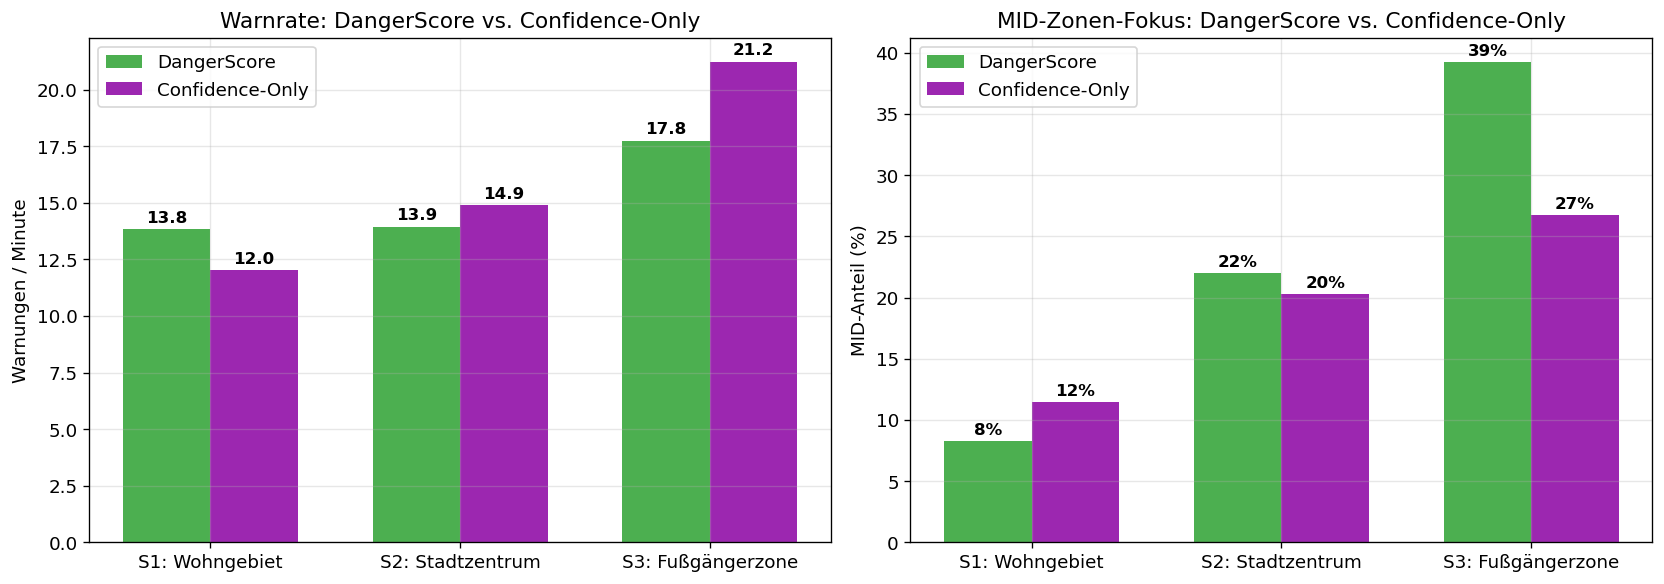

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scenarios = [s for s in ['S1', 'S2', 'S3'] if s in ds_agg and s in co_agg]
x = np.arange(len(scenarios))
width = 0.35

# Warnrate
ds_wr = [len(ds_agg[s]['we']) / max(1, ds_agg[s]['duration_s']) * 60 for s in scenarios]
co_wr = [len(co_agg[s]['we']) / max(1, co_agg[s]['duration_s']) * 60 for s in scenarios]

axes[0].bar(x - width/2, ds_wr, width, label='DangerScore', color=COLORS['DS'])
axes[0].bar(x + width/2, co_wr, width, label='Confidence-Only', color=COLORS['CO'])
axes[0].set_ylabel('Warnungen / Minute')
axes[0].set_title('Warnrate: DangerScore vs. Confidence-Only')
axes[0].set_xticks(x)
axes[0].set_xticklabels([SCENARIO_LABELS[s] for s in scenarios])
axes[0].legend()

# Werte über Balken
for i, (d, c) in enumerate(zip(ds_wr, co_wr)):
    axes[0].text(i - width/2, d + 0.3, f'{d:.1f}', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i + width/2, c + 0.3, f'{c:.1f}', ha='center', fontsize=10, fontweight='bold')

# MID-Anteil
ds_mid = [ds_agg[s]['we']['zone'].value_counts().get('MID', 0) / max(1, len(ds_agg[s]['we'])) * 100 for s in scenarios]
co_mid = [co_agg[s]['we']['zone'].value_counts().get('MID', 0) / max(1, len(co_agg[s]['we'])) * 100 for s in scenarios]

axes[1].bar(x - width/2, ds_mid, width, label='DangerScore', color=COLORS['DS'])
axes[1].bar(x + width/2, co_mid, width, label='Confidence-Only', color=COLORS['CO'])
axes[1].set_ylabel('MID-Anteil (%)')
axes[1].set_title('MID-Zonen-Fokus: DangerScore vs. Confidence-Only')
axes[1].set_xticks(x)
axes[1].set_xticklabels([SCENARIO_LABELS[s] for s in scenarios])
axes[1].legend()

for i, (d, c) in enumerate(zip(ds_mid, co_mid)):
    axes[1].text(i - width/2, d + 0.5, f'{d:.0f}%', ha='center', fontsize=10, fontweight='bold')
    axes[1].text(i + width/2, c + 0.5, f'{c:.0f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_ablation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Confidence-Verteilung zum Warnzeitpunkt

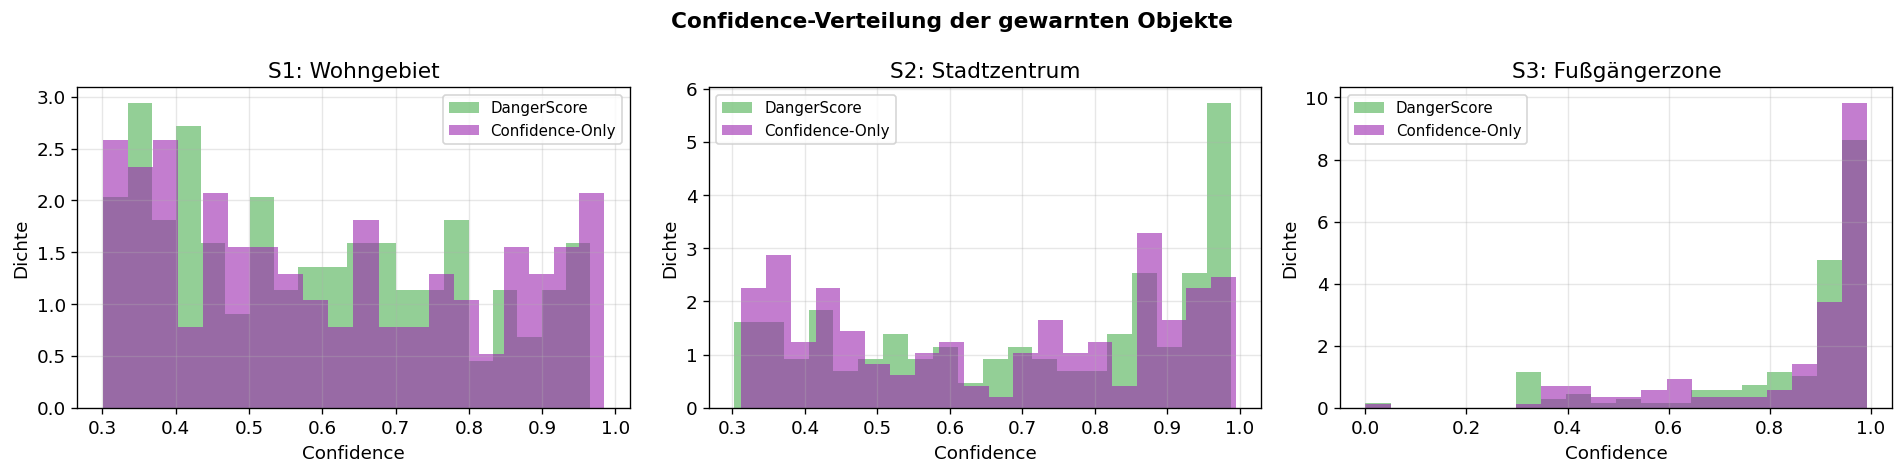

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, s in enumerate(['S1', 'S2', 'S3']):
    if s not in ds_agg or s not in co_agg:
        continue
    ds_conf = ds_agg[s]['we']['score']
    co_conf = co_agg[s]['we']['score']

    axes[i].hist(ds_conf, bins=20, alpha=0.6, color=COLORS['DS'], label='DangerScore', density=True)
    axes[i].hist(co_conf, bins=20, alpha=0.6, color=COLORS['CO'], label='Confidence-Only', density=True)
    axes[i].set_title(SCENARIO_LABELS[s])
    axes[i].set_xlabel('Confidence')
    axes[i].set_ylabel('Dichte')
    axes[i].legend(fontsize=9)

plt.suptitle('Confidence-Verteilung der gewarnten Objekte', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confidence_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Log-Vollstaendigkeit & Metadaten (FA-12 / NFA-07)

### 7.1 Vollstaendigkeitspruefung der CSV-Logs (FA-12)

In [38]:
EXPECTED_FM_COLS = [
    'timestamp_ms', 'fps', 'e2e_ms', 'pre_ms', 'inf_ms', 'post_ms',
    'cam_fps', 'drop_rate_pct', 'dropped_frames_est', 'is_stall',
    'det_count', 'selection_mode',
]
EXPECTED_WE_COLS = [
    'timestamp_ms', 'label_raw', 'score', 'zone', 'proximity',
    'area_ratio', 'danger_score', 'decision_reason', 'motion_hint',
]

print("=" * 70)
print("FA-12: Vollstaendigkeits- und Konsistenzpruefung der CSV-Logs")
print("=" * 70)

for mode_name, runs in [("DangerScore", ds_runs), ("Confidence-Only", co_runs)]:
    print(f"\n-- Modus: {mode_name} ({len(runs)} Laeufe) --")
    for key in sorted(runs.keys()):
        r = runs[key]
        fm = r['fm']
        we = r['we']

        fm_missing = [c for c in EXPECTED_FM_COLS if c not in fm.columns]
        fm_check_cols = [c for c in EXPECTED_FM_COLS if c in fm.columns]
        fm_nulls = fm[fm_check_cols].isnull().sum().sum() if fm_check_cols else -1

        we_missing = [c for c in EXPECTED_WE_COLS if c not in we.columns] if len(we) > 0 else []
        we_check_cols = [c for c in EXPECTED_WE_COLS if c in we.columns] if len(we) > 0 else []
        we_nulls = we[we_check_cols].isnull().sum().sum() if we_check_cols else 0

        s_fm = "ok" if not fm_missing and fm_nulls == 0 else "WARN"
        s_we = "ok" if not we_missing and we_nulls == 0 else "WARN"

        print(f"  {key}: FM {s_fm} ({len(fm)} rows, {fm_nulls} NaN) | "
              f"WE {s_we} ({len(we)} rows, {we_nulls} NaN)")
        if fm_missing:
            print(f"    FM fehlende Spalten: {fm_missing}")
        if we_missing:
            print(f"    WE fehlende Spalten: {we_missing}")

print("\n-- Zusammenfassung --")
all_fm = pd.concat([ds_runs[k]['fm'] for k in ds_runs], ignore_index=True)
all_we = pd.concat([ds_runs[k]['we'] for k in ds_runs if len(ds_runs[k]['we']) > 0], ignore_index=True)
print(f"  frame_metrics gesamt: {len(all_fm)} Zeilen, {all_fm.isnull().sum().sum()} NaN-Werte")
print(f"  warn_events gesamt:   {len(all_we)} Zeilen, {all_we.isnull().sum().sum()} NaN-Werte")
print(f"  Zusaetzliche FM-Spalten: {sorted(set(all_fm.columns) - set(EXPECTED_FM_COLS))}")
print(f"  Zusaetzliche WE-Spalten: {sorted(set(all_we.columns) - set(EXPECTED_WE_COLS))}")

FA-12: Vollstaendigkeits- und Konsistenzpruefung der CSV-Logs

-- Modus: DangerScore (9 Laeufe) --
  S1_L1: FM ok (1195 rows, 0 NaN) | WE ok (42 rows, 0 NaN)
  S1_L2: FM ok (1285 rows, 0 NaN) | WE ok (45 rows, 0 NaN)
  S1_L3: FM ok (1255 rows, 0 NaN) | WE ok (46 rows, 0 NaN)
  S2_L1: FM ok (1015 rows, 0 NaN) | WE ok (48 rows, 0 NaN)
  S2_L2: FM ok (985 rows, 0 NaN) | WE ok (43 rows, 0 NaN)
  S2_L3: FM ok (985 rows, 0 NaN) | WE ok (36 rows, 0 NaN)
  S3_L1: FM ok (715 rows, 0 NaN) | WE ok (33 rows, 0 NaN)
  S3_L2: FM ok (1045 rows, 0 NaN) | WE ok (66 rows, 0 NaN)
  S3_L3: FM ok (715 rows, 0 NaN) | WE ok (41 rows, 0 NaN)

-- Modus: Confidence-Only (9 Laeufe) --
  S1_L1: FM ok (1225 rows, 0 NaN) | WE ok (40 rows, 0 NaN)
  S1_L2: FM ok (1225 rows, 0 NaN) | WE ok (37 rows, 0 NaN)
  S1_L3: FM ok (1225 rows, 0 NaN) | WE ok (36 rows, 0 NaN)
  S2_L1: FM ok (1105 rows, 0 NaN) | WE ok (51 rows, 0 NaN)
  S2_L2: FM ok (1015 rows, 0 NaN) | WE ok (44 rows, 0 NaN)
  S2_L3: FM ok (1105 rows, 0 NaN) | WE

### 7.2 Metadaten und Reproduzierbarkeit (NFA-07)

In [39]:
metadata_cols = ['run_id', 'device_model', 'android_version', 'model_name',
                 'conf_threshold', 'nms_iou', 'selection_mode']

print("=" * 70)
print("NFA-07: Metadaten und Reproduzierbarkeit")
print("=" * 70)

sample_fm = list(ds_runs.values())[0]['fm']
sample_we = list(ds_runs.values())[0]['we'] if len(list(ds_runs.values())[0]['we']) > 0 else pd.DataFrame()

print("\nVerfuegbare Metadaten-Spalten:")
for col in metadata_cols:
    in_fm = col in sample_fm.columns
    in_we = col in sample_we.columns if len(sample_we) > 0 else False
    if in_fm or in_we:
        loc = []
        if in_fm: loc.append("FM")
        if in_we: loc.append("WE")
        print(f"  {col:<20s}: vorhanden in {' + '.join(loc)}")
    else:
        print(f"  {col:<20s}: nicht vorhanden")

rows = []
for mode_name, runs in [("DangerScore", ds_runs), ("Confidence-Only", co_runs)]:
    for key in sorted(runs.keys()):
        fm = runs[key]['fm']
        we = runs[key]['we']
        row = {'Modus': mode_name, 'Lauf': key}
        for col in metadata_cols:
            if col in fm.columns:
                row[col] = fm[col].iloc[0]
            elif len(we) > 0 and col in we.columns:
                row[col] = we[col].iloc[0]
            else:
                row[col] = '-'
        rows.append(row)

meta_df = pd.DataFrame(rows)
avail = [c for c in metadata_cols if c in meta_df.columns and (meta_df[c] != '-').any()]
if avail:
    display(meta_df[['Modus', 'Lauf'] + avail].style.set_caption(
        "Tabelle: Metadaten pro Lauf (NFA-07)"))
else:
    print("\nKeine der erwarteten Metadaten-Spalten in den Logs vorhanden.")

print("\n-- Feste Konfiguration (aus App-Parametern) --")
print("  Referenzgeraet:    Samsung Galaxy S20 FE (SM-G780G)")
print("  Android-Version:   13")
print("  Modellname:        YOLOv8n (obstacle_mvp_15c.onnx)")
print("  Eingabegroesse:    640x640")
print("  conf_threshold:    0.30")
print("  nms_iou:           0.45")
print("  selection_mode:    DANGER_SCORE_V1 / CONFIDENCE_ONLY")

NFA-07: Metadaten und Reproduzierbarkeit

Verfuegbare Metadaten-Spalten:
  run_id              : vorhanden in FM + WE
  device_model        : vorhanden in FM
  android_version     : vorhanden in FM
  model_name          : vorhanden in FM
  conf_threshold      : vorhanden in FM
  nms_iou             : vorhanden in FM
  selection_mode      : vorhanden in FM


,Modus,Lauf,run_id,device_model,android_version,model_name,conf_threshold,nms_iou,selection_mode
0,DangerScore,S1_L1,run_1772287922922,SM-G780G,33,obstacle_mvp_15c.onnx,0.300000,0.450000,DANGER_SCORE
1,DangerScore,S1_L2,run_1772288310446,SM-G780G,33,obstacle_mvp_15c.onnx,0.300000,0.450000,DANGER_SCORE
2,DangerScore,S1_L3,run_1772288707409,SM-G780G,33,obstacle_mvp_15c.onnx,0.300000,0.450000,DANGER_SCORE
3,DangerScore,S2_L1,run_1772202192974,SM-G780G,33,obstacle_mvp_15c.onnx,0.300000,0.450000,DANGER_SCORE
4,DangerScore,S2_L2,run_1772202666051,SM-G780G,33,obstacle_mvp_15c.onnx,0.300000,0.450000,DANGER_SCORE
5,DangerScore,S2_L3,run_1772203087741,SM-G780G,33,obstacle_mvp_15c.onnx,0.300000,0.450000,DANGER_SCORE
6,DangerScore,S3_L1,run_1772200036069,SM-G780G,33,obstacle_mvp_15c.onnx,0.300000,0.450000,DANGER_SCORE
7,DangerScore,S3_L2,run_1772200398426,SM-G780G,33,obstacle_mvp_15c.onnx,0.300000,0.450000,DANGER_SCORE
8,DangerScore,S3_L3,run_1772200762236,SM-G780G,33,obstacle_mvp_15c.onnx,0.300000,0.450000,DANGER_SCORE
9,Confidence-Only,S1_L1,run_1772282530503,SM-G780G,33,obstacle_mvp_15c.onnx,0.300000,0.450000,CONFIDENCE_ONLY



-- Feste Konfiguration (aus App-Parametern) --
  Referenzgeraet:    Samsung Galaxy S20 FE (SM-G780G)
  Android-Version:   13
  Modellname:        YOLOv8n (obstacle_mvp_15c.onnx)
  Eingabegroesse:    640x640
  conf_threshold:    0.30
  nms_iou:           0.45
  selection_mode:    DANGER_SCORE_V1 / CONFIDENCE_ONLY


## 8. Szenariouebergreifende Gesamtuebersicht

In [40]:
def gesamttabelle():
    rows = []
    for mode_name, agg_dict in [("DangerScore", ds_agg), ("Confidence-Only", co_agg)]:
        for s in ['S1', 'S2', 'S3']:
            if s not in agg_dict:
                continue
            fm = agg_dict[s]['fm']
            we = agg_dict[s]['we']
            dur = agg_dict[s]['duration_s']
            n_we = len(we)
            rows.append({
                'Modus': mode_name,
                'Szenario': SCENARIO_LABELS[s],
                'Frames': len(fm),
                'Dauer (s)': int(dur),
                'fps mean': round(fm['fps'].mean(), 1),
                'e2e p50 (ms)': int(fm['e2e_ms'].median()),
                'e2e p90 (ms)': int(fm['e2e_ms'].quantile(0.9)),
                'det mean': round(fm['det_count'].mean(), 1),
                'Stall (%)': round(fm['is_stall'].mean() * 100, 2),
                'Warnungen': n_we,
                'Warn/min': round(n_we / max(1, dur) * 60, 1),
                'MID (%)': round(we['zone'].value_counts().get('MID', 0) / max(1, n_we) * 100, 0) if n_we > 0 else 0,
            })
    return pd.DataFrame(rows)

display(gesamttabelle().style.format(precision=2).set_caption(
    "Tabelle: Gesamtübersicht aller Szenarien und Modi").hide(axis='index'))

Modus,Szenario,Frames,Dauer (s),fps mean,e2e p50 (ms),e2e p90 (ms),det mean,Stall (%),Warnungen,Warn/min,MID (%)
DangerScore,S1: Wohngebiet,3735,576,6.50,147,160,1.20,0.00,133,13.80,8.00
DangerScore,S2: Stadtzentrum,2985,546,5.70,162,211,2.00,0.07,127,13.90,22.00
DangerScore,S3: Fußgängerzone,2475,473,6.10,157,202,6.30,0.08,140,17.80,39.00
Confidence-Only,S1: Wohngebiet,3675,563,6.60,147,156,1.10,0.00,113,12.00,12.00
Confidence-Only,S2: Stadtzentrum,3225,576,5.70,163,211,1.90,0.00,143,14.90,20.00
Confidence-Only,S3: Fußgängerzone,2565,485,6.00,158,211,5.70,0.08,172,21.20,27.00


### Pro-Lauf-Details

In [41]:
def per_run_table(runs_dict, mode_label):
    rows = []
    for key in sorted(runs_dict.keys()):
        r = runs_dict[key]
        fm = r['fm']
        we = r['we']
        dur = r['duration_s']
        n_we = len(we)
        mid = we['zone'].value_counts().get('MID', 0) / max(1, n_we) * 100 if n_we > 0 else 0
        rows.append({
            'Lauf': key,
            'Frames': len(fm),
            'Dauer (s)': int(dur),
            'fps mean': round(fm['fps'].mean(), 1),
            'e2e p50': int(fm['e2e_ms'].median()),
            'det mean': round(fm['det_count'].mean(), 1),
            'Warnungen': n_we,
            'Warn/min': round(n_we / max(1, dur) * 60, 1),
            'MID (%)': round(mid, 0),
        })
    return pd.DataFrame(rows).set_index('Lauf')

display(per_run_table(ds_runs, "DangerScore").style.format(precision=2).set_caption("Tabelle: Pro-Lauf-Details (DangerScore-Modus)"))
print()
display(per_run_table(co_runs, "Confidence-Only").style.format(precision=2).set_caption("Tabelle: Pro-Lauf-Details (Confidence-Only-Modus)"))

,Frames,Dauer (s),fps mean,e2e p50,det mean,Warnungen,Warn/min,MID (%)
Lauf,,,,,,,,
S1_L1,1195,186,6.40,149,1.20,42,13.50,10.00
S1_L2,1285,196,6.60,146,1.30,45,13.70,9.00
S1_L3,1255,193,6.60,147,1.10,46,14.30,7.00
S2_L1,1015,187,5.90,159,2.00,48,15.40,19.00
S2_L2,985,179,5.60,167,2.30,43,14.40,30.00
S2_L3,985,179,5.60,166,1.60,36,12.00,17.00
S3_L1,715,179,6.10,157,6.20,33,11.00,42.00
S3_L2,1045,177,6.00,158,6.40,66,22.30,38.00
S3_L3,715,116,6.20,153,6.40,41,21.10,39.00


,Frames,Dauer (s),fps mean,e2e p50,det mean,Warnungen,Warn/min,MID (%)
Lauf,,,,,,,,
S1_L1,1225,189,6.50,148,1.10,40,12.70,12.00
S1_L2,1225,188,6.60,147,1.10,37,11.80,11.00
S1_L3,1225,186,6.60,146,1.30,36,11.60,11.00
S2_L1,1105,184,6.10,158,2.40,51,16.50,25.00
S2_L2,1015,183,5.70,163,1.80,44,14.40,16.00
S2_L3,1105,207,5.50,183,1.60,48,13.90,19.00
S3_L1,715,116,6.20,153,7.20,44,22.60,23.00
S3_L2,835,187,6.10,154,5.20,52,16.70,31.00
S3_L3,1015,181,5.70,164,4.90,76,25.10,26.00


## 9. Anforderungs-Deckungsmatrix

In [42]:
coverage = pd.DataFrame([
    {'ID': 'FA-01', 'Anforderung': 'Echtzeit-Bilderfassung', 'Status': 'Notebook', 'Abschnitt': '3.1, 3.3'},
    {'ID': 'FA-02', 'Anforderung': 'Objekterkennung (Training)', 'Status': 'Notebook', 'Abschnitt': '2.1-2.4'},
    {'ID': 'FA-03', 'Anforderung': 'Klassifikation Hindernisklassen', 'Status': 'Notebook + sep. Datei', 'Abschnitt': '2.5-2.7'},
    {'ID': 'FA-04', 'Anforderung': 'Raeumliche Zonenzuordnung', 'Status': 'Notebook', 'Abschnitt': '5.3'},
    {'ID': 'FA-05', 'Anforderung': 'Naeherungsschaetzung', 'Status': 'Notebook', 'Abschnitt': '5.4, 5.4b'},
    {'ID': 'FA-06', 'Anforderung': 'Gefahrenbewertung', 'Status': 'Notebook', 'Abschnitt': '5.5, 5.5b, 6.x'},
    {'ID': 'FA-07', 'Anforderung': 'Auditive Warnausgabe', 'Status': 'Notebook', 'Abschnitt': '5.1, 5.6'},
    {'ID': 'FA-08', 'Anforderung': 'Warnstabilisierung', 'Status': 'Notebook', 'Abschnitt': '5.6, 5.6b'},
    {'ID': 'FA-09', 'Anforderung': 'Bewegungstrenderkennung', 'Status': 'Notebook', 'Abschnitt': '5.7'},
    {'ID': 'FA-10', 'Anforderung': 'Orientierungshinweise', 'Status': 'Notebook', 'Abschnitt': '5.8'},
    {'ID': 'FA-11', 'Anforderung': 'Visuelle Overlay-Darstellung', 'Status': 'Separates Dokument', 'Abschnitt': 'Anhang'},
    {'ID': 'FA-12', 'Anforderung': 'Strukturierte Messdatenerfassung', 'Status': 'Notebook', 'Abschnitt': '7.1'},
    {'ID': 'NFA-01', 'Anforderung': 'Echtzeitfaehigkeit', 'Status': 'Notebook', 'Abschnitt': '3.1, 3.3'},
    {'ID': 'NFA-02', 'Anforderung': 'Ressourceneffizienz', 'Status': 'Notebook', 'Abschnitt': '3.2, 3.3'},
    {'ID': 'NFA-03', 'Anforderung': 'Offline-Faehigkeit', 'Status': 'Separates Dokument', 'Abschnitt': 'Code-Analyse'},
    {'ID': 'NFA-04', 'Anforderung': 'Datenschutz', 'Status': 'Separates Dokument', 'Abschnitt': 'Code-Analyse'},
    {'ID': 'NFA-05', 'Anforderung': 'Robustheit und Stabilitaet', 'Status': 'Notebook', 'Abschnitt': '3.3, 4.1'},
    {'ID': 'NFA-07', 'Anforderung': 'Nachvollziehbarkeit', 'Status': 'Notebook', 'Abschnitt': '7.2'},
    {'ID': 'NFA-08', 'Anforderung': 'Portabilitaet', 'Status': 'Separates Dokument', 'Abschnitt': 'Code-Analyse'},
])

display(coverage.style.set_caption("Anforderungs-Deckungsmatrix").hide(axis='index'))

ID,Anforderung,Status,Abschnitt
FA-01,Echtzeit-Bilderfassung,Notebook,"3.1, 3.3"
FA-02,Objekterkennung (Training),Notebook,2.1-2.4
FA-03,Klassifikation Hindernisklassen,Notebook + sep. Datei,2.5-2.7
FA-04,Raeumliche Zonenzuordnung,Notebook,5.3
FA-05,Naeherungsschaetzung,Notebook,"5.4, 5.4b"
FA-06,Gefahrenbewertung,Notebook,"5.5, 5.5b, 6.x"
FA-07,Auditive Warnausgabe,Notebook,"5.1, 5.6"
FA-08,Warnstabilisierung,Notebook,"5.6, 5.6b"
FA-09,Bewegungstrenderkennung,Notebook,5.7
FA-10,Orientierungshinweise,Notebook,5.8
